In [ ]:
# =============================================================================
# SENARYO 5: FEDERE BİLGİ DAMITMA (Teacher-Student)
# HÜCRE 1: ORTAM KURULUMU VE H100 YAPILANDIRMASI
# =============================================================================

import os, gc, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                             recall_score, confusion_matrix, roc_curve,
                             classification_report, precision_recall_curve)
import tensorflow as tf
from tensorflow.keras import mixed_precision
import joblib
warnings.filterwarnings('ignore')

print("=" * 65)
print("   SENARYO 5 — HÜCRE 1: ORTAM HAZIRLIĞI")
print("=" * 65)

# --- Drive ---
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive bağlandı.")

# --- GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU Aktif: {len(gpus)} adet")
    for i, gpu in enumerate(gpus):
        details = tf.config.experimental.get_device_details(gpu)
        print(f"   -> GPU {i}: {details.get('device_name', 'Bilinmiyor')}")
else:
    print("⚠️ GPU Bulunamadı!")

# --- Mixed Precision + XLA (Senaryo 1 ile aynı) ---
mixed_precision.set_global_policy('mixed_bfloat16')
print(f"✅ Mixed Precision: {mixed_precision.global_policy().name}")
tf.config.optimizer.set_jit(True)
print("✅ XLA JIT Derleme: AKTİF")

# =============================================================================
# GLOBAL SABİTLER — Senaryo 1 ile TAM AYNI (adil karşılaştırma için)
# =============================================================================
ROOT_PATH      = '/content/drive/MyDrive/wifi_mqtt'
SAVE_PATH      = '/content/drive/MyDrive/wifi_mqtt'

# Veri
TIME_STEPS     = 20
TEST_SIZE      = 0.20
PCA_VARIANCE   = 0.95
PCA_COMPONENTS = 20
SEED           = 42

# Federe eğitim
ROUNDS         = 50
LOCAL_EPOCHS   = 8
BATCH_SIZE     = 8192
LEARNING_RATE  = 0.001

# Distillation (Senaryo 5'e özel)
ALPHA          = 0.4    # reconstruction loss ağırlığı
BETA           = 0.6    # distillation (latent MSE) ağırlığı

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"\n📋 GLOBAL SABİTLER:")
print(f"   ROOT_PATH      : {ROOT_PATH}")
print(f"   Klasör var mı  : {os.path.exists(ROOT_PATH)}")
print(f"   TIME_STEPS     : {TIME_STEPS}")
print(f"   PCA_COMPONENTS : {PCA_COMPONENTS}")
print(f"   BATCH_SIZE     : {BATCH_SIZE}")
print(f"   ROUNDS         : {ROUNDS}")
print(f"   LOCAL_EPOCHS   : {LOCAL_EPOCHS}")
print(f"   LEARNING_RATE  : {LEARNING_RATE}")
print(f"   ALPHA (recon)  : {ALPHA}")
print(f"   BETA  (distil) : {BETA}")
print(f"\n✅ TensorFlow : {tf.__version__}")
print(f"✅ NumPy      : {np.__version__}")

print("\n" + "=" * 65)
print("   HÜCRE 1 TAMAMLANDI — HÜCRE 2'YE GEÇEBİLİRSİNİZ")
print("=" * 65)

   SENARYO 5 — HÜCRE 1: ORTAM HAZIRLIĞI
Mounted at /content/drive
✅ Google Drive bağlandı.
✅ GPU Aktif: 1 adet
   -> GPU 0: NVIDIA A100-SXM4-40GB
✅ Mixed Precision: mixed_bfloat16
✅ XLA JIT Derleme: AKTİF

📋 GLOBAL SABİTLER:
   ROOT_PATH      : /content/drive/MyDrive/wifi_mqtt
   Klasör var mı  : True
   TIME_STEPS     : 20
   PCA_COMPONENTS : 20
   BATCH_SIZE     : 8192
   ROUNDS         : 50
   LOCAL_EPOCHS   : 8
   LEARNING_RATE  : 0.001
   ALPHA (recon)  : 0.4
   BETA  (distil) : 0.6

✅ TensorFlow : 2.20.0
✅ NumPy      : 2.0.2

   HÜCRE 1 TAMAMLANDI — HÜCRE 2'YE GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# SENARYO 5: FEDERE BİLGİ DAMITMA — HÜCRE 2
# VERİ YÜKLEME, TEMİZLEME, SCALING VE OTOMATİK PCA
# =============================================================================
# Senaryo 1 ile TAMAMEN AYNI — adil karşılaştırma için değiştirilmedi
# PCA burada FIT edilir → sonraki hücrelerde TRANSFORM uygulanır
# =============================================================================

import os, gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("=" * 65)
print("   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. NORMAL (PROFİLİNG) DOSYALARINI TARA
# -----------------------------------------------------------------------------
print("\n📂 Normal (Profiling) dosyaları taranıyor...")
all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   -> Bulunan toplam dosya: {len(all_benign_files)}")

if not all_benign_files:
    raise ValueError("❌ Hiç profiling dosyası bulunamadı! ROOT_PATH'i kontrol et.")

# -----------------------------------------------------------------------------
# 2. TÜM DOSYALARI YÜKLE VE BİRLEŞTİR
# -----------------------------------------------------------------------------
print("\n⏳ Dosyalar yükleniyor...")
dfs = []
for f in all_benign_files:
    try:
        df = pd.read_csv(f)
        df = df.select_dtypes(include=[np.number]).astype('float32')
        dfs.append(df)
    except Exception as e:
        print(f"   ⚠️ Atlandı ({os.path.basename(f)}): {e}")

df_full = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()
print(f"   -> Ham veri boyutu: {df_full.shape}")

# -----------------------------------------------------------------------------
# 3. TEMİZLEME
# -----------------------------------------------------------------------------
print("\n🧹 Veri temizleniyor...")
df_full.replace([np.inf, -np.inf], np.nan, inplace=True)
df_full.dropna(inplace=True)

varyanslar = df_full.var()
sifir_var  = varyanslar[varyanslar == 0].index.tolist()
df_full.drop(columns=sifir_var, inplace=True)

print(f"   -> Silinen sabit kolonlar ({len(sifir_var)} adet): {sifir_var}")
print(f"   -> Temizleme sonrası boyut: {df_full.shape}")

FEATURE_COLUMNS = df_full.columns.tolist()
print(f"   -> Kullanılacak özellik sayısı: {len(FEATURE_COLUMNS)}")

# -----------------------------------------------------------------------------
# 4. GLOBAL STANDARD SCALING
# -----------------------------------------------------------------------------
print("\n⚡ StandardScaler fit ediliyor (tüm normal veri üzerinde)...")
scaler = StandardScaler()
scaled_full = scaler.fit_transform(df_full).astype(np.float32)
print(f"   -> Scaler fit tamamlandı: mean={scaler.mean_[:3].round(3)} ...")

# -----------------------------------------------------------------------------
# 5. OTOMATİK PCA — %95 VARYANS
# -----------------------------------------------------------------------------
print(f"\n🔬 PCA fit ediliyor (hedef varyans: %{PCA_VARIANCE*100:.0f})...")

pca_full = PCA(n_components=PCA_VARIANCE, random_state=SEED)
pca_full.fit(scaled_full)
n_components_auto = pca_full.n_components_
explained          = pca_full.explained_variance_ratio_.sum()

print(f"   -> Otomatik bileşen sayısı : {n_components_auto}")
print(f"   -> Açıklanan varyans       : %{explained*100:.2f}")

# Sabit bileşen sayısı ile yeniden fit (Senaryo 1 ile aynı: 20)
print(f"\n   PCA_COMPONENTS = {PCA_COMPONENTS} ile yeniden fit ediliyor...")
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
pca.fit(scaled_full)
explained_fixed = pca.explained_variance_ratio_.sum()
print(f"   -> {PCA_COMPONENTS} bileşen ile açıklanan varyans: %{explained_fixed*100:.2f}")

del scaled_full
gc.collect()

# -----------------------------------------------------------------------------
# 6. SCALER VE PCA'Yİ KAYDET
# -----------------------------------------------------------------------------
joblib.dump(scaler, f'{SAVE_PATH}/s5_scaler.pkl')
joblib.dump(pca,    f'{SAVE_PATH}/s5_pca.pkl')
print(f"\n✅ Scaler kaydedildi : s5_scaler.pkl")
print(f"✅ PCA    kaydedildi : s5_pca.pkl")

# -----------------------------------------------------------------------------
# 7. ÖZET
# -----------------------------------------------------------------------------
print(f"\n📊 ÖZET:")
print(f"   -> Toplam veri boyutu    : {df_full.shape}")
print(f"   -> Açıklanan varyans     : %{explained_fixed*100:.2f}")
print(f"   -> PCA_COMPONENTS        : {PCA_COMPONENTS}")
print(f"   -> FEATURE_COLUMNS sayısı: {len(FEATURE_COLUMNS)}")

print("\n" + "=" * 65)
print("   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR

📂 Normal (Profiling) dosyaları taranıyor...
   -> Bulunan toplam dosya: 42

⏳ Dosyalar yükleniyor...
   -> Ham veri boyutu: (389956, 45)

🧹 Veri temizleniyor...
   -> Silinen sabit kolonlar (5 adet): ['Drate', 'Telnet', 'SMTP', 'SSH', 'IRC']
   -> Temizleme sonrası boyut: (389956, 40)
   -> Kullanılacak özellik sayısı: 40

⚡ StandardScaler fit ediliyor (tüm normal veri üzerinde)...
   -> Scaler fit tamamlandı: mean=[8.64343552e+05 8.62700000e+00 7.68470000e+01] ...

🔬 PCA fit ediliyor (hedef varyans: %95)...
   -> Otomatik bileşen sayısı : 20
   -> Açıklanan varyans       : %95.34

   PCA_COMPONENTS = 20 ile yeniden fit ediliyor...
   -> 20 bileşen ile açıklanan varyans: %95.34

✅ Scaler kaydedildi : s5_scaler.pkl
✅ PCA    kaydedildi : s5_pca.pkl

📊 ÖZET:
   -> Toplam veri boyutu    : (389956, 40)
   -> Açıklanan varyans     : %95.34
   -> PCA_COMPONENTS        : 20
   -> FEATURE_COLUMNS sayısı: 40

   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİ

In [ ]:
# =============================================================================
# SENARYO 5: FEDERE BİLGİ DAMITMA — HÜCRE 3 (FINAL)
# CLIENT BAZLI VERİ BÖLME, SEQUENCE VE tf.data
# =============================================================================

import gc, os
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 65)
print("   CLIENT BAZLI VERİ HAZIRLAMA BAŞLATILIYOR")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. CLIENT DOSYA LİSTESİ
# -----------------------------------------------------------------------------
print("\n📂 Client dosya listesi oluşturuluyor...")

wifi_files = []
mqtt_files = []

for f in all_benign_files:
    fname = os.path.basename(f).lower()
    if 'mqtt' in fname:
        mqtt_files.append(f)
    else:
        wifi_files.append(f)

if len(mqtt_files) < 2:
    print("   ⚠️  İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...")
    mid        = len(all_benign_files) // 2
    wifi_files = all_benign_files[:mid]
    mqtt_files = all_benign_files[mid:]

print(f"   -> Client 1 (WiFi)  dosya sayısı: {len(wifi_files)}")
print(f"   -> Client 2 (MQTT)  dosya sayısı: {len(mqtt_files)}")

# -----------------------------------------------------------------------------
# 2. CLIENT DATAFRAME'LERİ
# -----------------------------------------------------------------------------
print("\n⏳ Client dataframe'leri oluşturuluyor...")

def load_client_df(file_list, client_name):
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ {client_name} - Atlandı: {os.path.basename(f)}: {e}")
    result = pd.concat(dfs, ignore_index=True)
    print(f"   -> {client_name}: {result.shape}")
    return result

df_wifi  = load_client_df(wifi_files, "Client 1 (WiFi)")
df_mqtt  = load_client_df(mqtt_files, "Client 2 (MQTT)")

cut_wifi = int(len(df_wifi) * 0.80)
cut_mqtt = int(len(df_mqtt) * 0.80)
df_mixed = pd.concat(
    [df_wifi.iloc[cut_wifi:], df_mqtt.iloc[cut_mqtt:]],
    ignore_index=True
)
print(f"   -> Client 3 (Mixed): {df_mixed.shape}")

# -----------------------------------------------------------------------------
# 3. SEQUENCE OLUŞTURMA
# -----------------------------------------------------------------------------
def create_sequences_fast(data, time_steps):
    n_samples  = data.shape[0] - time_steps
    n_features = data.shape[1]
    shape      = (n_samples, time_steps, n_features)
    strides    = (data.strides[0], data.strides[0], data.strides[1])
    seq        = np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)
    return np.array(seq, dtype=np.float32)

# -----------------------------------------------------------------------------
# 4. SCALE → PCA → SEQUENCE
# -----------------------------------------------------------------------------
print(f"\n⚡ Scale → PCA → Sequence pipeline uygulanıyor...")

def apply_pipeline(df, client_name):
    scaled    = scaler.transform(df).astype(np.float32)
    pca_trans = pca.transform(scaled).astype(np.float32)
    sequences = create_sequences_fast(pca_trans, TIME_STEPS)
    print(f"   -> {client_name}: sequence shape = {sequences.shape}"
          f"  | RAM = {sequences.nbytes / 1e6:.1f} MB")
    return sequences

X_client1 = apply_pipeline(df_wifi,  "Client 1 (WiFi)")
X_client2 = apply_pipeline(df_mqtt,  "Client 2 (MQTT)")
X_client3 = apply_pipeline(df_mixed, "Client 3 (Mixed)")

del df_wifi, df_mqtt, df_mixed, df_full
gc.collect()

# -----------------------------------------------------------------------------
# 5. TRAIN / VAL SPLIT
# -----------------------------------------------------------------------------
print(f"\n✂️  Kronolojik Train/Val bölmesi yapılıyor (%80/%20)...")

def split_client(X, name):
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_tr  = X[:split_idx]
    X_val = X[split_idx:]
    print(f"   -> {name}: train={X_tr.shape} | val={X_val.shape}")
    return X_tr, X_val

X_tr1, X_val1 = split_client(X_client1, "Client 1 (WiFi)")
X_tr2, X_val2 = split_client(X_client2, "Client 2 (MQTT)")
X_tr3, X_val3 = split_client(X_client3, "Client 3 (Mixed)")

# -----------------------------------------------------------------------------
# 6. tf.data PIPELINE — CPU'da oluştur, GPU'ya prefetch et
# CUDA_ERROR_INVALID_HANDLE hatasını önlemek için with CPU:0 bloğu
# -----------------------------------------------------------------------------
print(f"\n⚡ tf.data pipeline kuruluyor (batch={BATCH_SIZE})...")

AUTOTUNE = tf.data.AUTOTUNE

def make_tf_datasets(X_tr, X_val, client_name):
    with tf.device('/CPU:0'):
        train_ds = (
            tf.data.Dataset.from_tensor_slices((X_tr, X_tr))
            .shuffle(buffer_size=15000, seed=SEED)
            .batch(BATCH_SIZE, drop_remainder=True)
            .prefetch(AUTOTUNE)
        )
        val_ds = (
            tf.data.Dataset.from_tensor_slices((X_val, X_val))
            .batch(BATCH_SIZE, drop_remainder=False)
            .prefetch(AUTOTUNE)
        )
    print(f"   -> {client_name}: "
          f"train_batches={len(train_ds)} | val_batches={len(val_ds)}")
    return train_ds, val_ds

train_ds1, val_ds1 = make_tf_datasets(X_tr1, X_val1, "Client 1 (WiFi)")
train_ds2, val_ds2 = make_tf_datasets(X_tr2, X_val2, "Client 2 (MQTT)")
train_ds3, val_ds3 = make_tf_datasets(X_tr3, X_val3, "Client 3 (Mixed)")

CLIENT_DATASETS = [
    {"name": "WiFi",  "train": train_ds1, "val": val_ds1,
     "n_train": len(X_tr1), "n_val": len(X_val1)},
    {"name": "MQTT",  "train": train_ds2, "val": val_ds2,
     "n_train": len(X_tr2), "n_val": len(X_val2)},
    {"name": "Mixed", "train": train_ds3, "val": val_ds3,
     "n_train": len(X_tr3), "n_val": len(X_val3)},
]

for batch_x, batch_y in train_ds1.take(1):
    print(f"\n✅ Örnek batch kontrolü (Client 1):")
    print(f"   -> batch_x shape : {batch_x.shape}")
    print(f"   -> dtype         : {batch_x.dtype}")

print("\n" + "=" * 65)
print("   HÜCRE 3 TAMAMLANDI — HÜCRE 4'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   CLIENT BAZLI VERİ HAZIRLAMA BAŞLATILIYOR

📂 Client dosya listesi oluşturuluyor...
   ⚠️  İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...
   -> Client 1 (WiFi)  dosya sayısı: 21
   -> Client 2 (MQTT)  dosya sayısı: 21

⏳ Client dataframe'leri oluşturuluyor...
   -> Client 1 (WiFi): (131133, 40)
   -> Client 2 (MQTT): (258823, 40)
   -> Client 3 (Mixed): (77992, 40)

⚡ Scale → PCA → Sequence pipeline uygulanıyor...
   -> Client 1 (WiFi): sequence shape = (131113, 20, 20)  | RAM = 209.8 MB
   -> Client 2 (MQTT): sequence shape = (258803, 20, 20)  | RAM = 414.1 MB
   -> Client 3 (Mixed): sequence shape = (77972, 20, 20)  | RAM = 124.8 MB

✂️  Kronolojik Train/Val bölmesi yapılıyor (%80/%20)...
   -> Client 1 (WiFi): train=(104890, 20, 20) | val=(26223, 20, 20)
   -> Client 2 (MQTT): train=(207042, 20, 20) | val=(51761, 20, 20)
   -> Client 3 (Mixed): train=(62377, 20, 20) | val=(15595, 20, 20)

⚡ tf.data pipeline kuruluyor (batch=8192)...
   -> Client 1 (WiFi): train_bat

In [ ]:
# =============================================================================
# SENARYO 5 — HÜCRE 4 (FINAL): TEACHER — S1 MİMARİSİ (TAM EŞLEŞTİRME)
# =============================================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, mixed_precision
import numpy as np

mixed_precision.set_global_policy('float32')
tf.keras.backend.clear_session()

print("=" * 65)
print("   TEACHER MODEL — S1 MİMARİSİ (config.json'dan)")
print("=" * 65)

def combined_reconstruction_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae    = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse    = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

def build_teacher_model(time_steps, n_features):
    inputs = layers.Input(shape=(time_steps, n_features),
                          dtype='float32', name='input')

    # ── ENCODER ──────────────────────────────────────────────────────
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu', name='conv_local')(inputs)

    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True),
            name='bilstm_encoder'
        )(x)                                          # (T, 256)

    x = layers.Dropout(0.1, name='drop_enc_1')(x)

    # Encoder Transformer (pre-norm)
    _res = x
    x    = layers.LayerNormalization(name='enc_transformer_ln1')(x)
    x    = layers.MultiHeadAttention(
               num_heads=4, key_dim=64,
               name='enc_transformer_mha'
           )(x, x)
    x    = layers.Add(name='enc_transformer_add1')([_res, x])
    _res = x
    x    = layers.LayerNormalization(name='enc_transformer_ln2')(x)
    x    = layers.Dense(512, activation='relu',
                        name='enc_transformer_ff1')(x)
    x    = layers.Dropout(0.1, name='enc_transformer_drop')(x)
    x    = layers.Dense(256, name='enc_transformer_ff2')(x)
    x    = layers.Add(name='enc_transformer_add2')([_res, x])  # (T, 256)

    # ── BOTTLENECK ───────────────────────────────────────────────────
    x = layers.LSTM(64, return_sequences=True,
                    name='bottleneck')(x)             # (T, 64)
    x = layers.LayerNormalization(name='bottleneck_ln')(x)

    # Bottleneck Transformer (pre-norm)
    _res = x
    x    = layers.LayerNormalization(name='bottleneck_transformer_ln1')(x)
    x    = layers.MultiHeadAttention(
               num_heads=4, key_dim=16,
               name='bottleneck_transformer_mha'
           )(x, x)
    x    = layers.Add(name='bottleneck_transformer_add1')([_res, x])
    _res = x
    x    = layers.LayerNormalization(name='bottleneck_transformer_ln2')(x)
    x    = layers.Dense(128, activation='relu',
                        name='bottleneck_transformer_ff1')(x)
    x    = layers.Dropout(0.1, name='bottleneck_transformer_drop')(x)
    x    = layers.Dense(64, name='bottleneck_transformer_ff2')(x)
    x    = layers.Add(name='bottleneck_transformer_add2')([_res, x])  # (T, 64)

    # ── DECODER ──────────────────────────────────────────────────────
    x = layers.LSTM(128, return_sequences=True,
                    name='lstm_dec_1')(x)             # (T, 128)
    x = layers.Dropout(0.1, name='drop_dec_1')(x)

    # Decoder Transformer (pre-norm)
    _res = x
    x    = layers.LayerNormalization(name='dec_transformer_ln1')(x)
    x    = layers.MultiHeadAttention(
               num_heads=4, key_dim=32,
               name='dec_transformer_mha'
           )(x, x)
    x    = layers.Add(name='dec_transformer_add1')([_res, x])
    _res = x
    x    = layers.LayerNormalization(name='dec_transformer_ln2')(x)
    x    = layers.Dense(256, activation='relu',
                        name='dec_transformer_ff1')(x)
    x    = layers.Dropout(0.1, name='dec_transformer_drop')(x)
    x    = layers.Dense(128, name='dec_transformer_ff2')(x)
    x    = layers.Add(name='dec_transformer_add2')([_res, x])  # (T, 128)

    x = layers.LSTM(256, return_sequences=True,
                    name='lstm_dec_2')(x)             # (T, 256)
    x = layers.Dropout(0.1, name='drop_dec_2')(x)

    outputs = layers.TimeDistributed(
        layers.Dense(n_features, dtype='float32'),
        name='output_dense'
    )(x)                                              # (T, 20)

    model = Model(inputs=inputs, outputs=outputs, name='teacher_mha_lstm')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE, clipvalue=0.5, epsilon=1e-7
        ),
        loss=combined_reconstruction_loss
    )
    return model

# Build
teacher_model  = build_teacher_model(TIME_STEPS, PCA_COMPONENTS)
global_weights = teacher_model.get_weights()

print(f"\n📊 Teacher Model:")
print(f"   -> Toplam parametre  : {teacher_model.count_params():,}")
print(f"   -> Model boyutu      : {teacher_model.count_params() * 4 / 1e6:.1f} MB")
print(f"   -> Input shape       : {teacher_model.input_shape[1:]}")
print(f"   -> Output shape      : {teacher_model.output_shape[1:]}")

# Teacher Encoder — bottleneck çıkışı
teacher_encoder = Model(
    inputs  = teacher_model.input,
    outputs = teacher_model.get_layer('bottleneck').output,
    name    = 'teacher_encoder'
)
TEACHER_LATENT_DIM = teacher_encoder.output_shape[-1]

print(f"\n📦 Teacher Encoder:")
print(f"   -> Output shape       : {teacher_encoder.output_shape}")
print(f"   -> TEACHER_LATENT_DIM : {TEACHER_LATENT_DIM}")
print(f"\n✅ global_weights hazır — {len(global_weights)} katman ağırlığı")

mixed_precision.set_global_policy('mixed_bfloat16')
print(f"✅ Mixed Precision: {mixed_precision.global_policy().name}")

print("\n" + "=" * 65)
print("   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   TEACHER MODEL — S1 MİMARİSİ (config.json'dan)

📊 Teacher Model:
   -> Toplam parametre  : 1,475,092
   -> Model boyutu      : 5.9 MB
   -> Input shape       : (20, 20)
   -> Output shape      : (20, 20)

📦 Teacher Encoder:
   -> Output shape       : (None, 20, 64)
   -> TEACHER_LATENT_DIM : 64

✅ global_weights hazır — 69 katman ağırlığı
✅ Mixed Precision: mixed_bfloat16

   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# SENARYO 5 — HÜCRE 5: TEACHER AĞIRLIK YÜKLE
# =============================================================================

import zipfile, os
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model

print("=" * 65)
print("   TEACHER AĞIRLIK YÜKLEME")
print("=" * 65)

TEACHER_PATH = '/content/drive/MyDrive/federe_mha_lstm_outputs_ROUND/federe_mha_lstm_best.keras'
WEIGHTS_PATH = '/tmp/teacher_keras_extract/model.weights.h5'

# Daha önce extract ettik, dosya var mı kontrol
if not os.path.exists(WEIGHTS_PATH):
    print("⏳ .keras açılıyor...")
    os.makedirs('/tmp/teacher_keras_extract', exist_ok=True)
    with zipfile.ZipFile(TEACHER_PATH, 'r') as zf:
        zf.extractall('/tmp/teacher_keras_extract')

print(f"   Weights dosyası: {os.path.getsize(WEIGHTS_PATH)/1e6:.2f} MB")

# Ağırlıkları yükle
print("\n⏳ Ağırlıklar yükleniyor...")
teacher_model.load_weights(WEIGHTS_PATH)
print("   ✅ Ağırlıklar başarıyla yüklendi!")

# Encoder güncelle — return_sequences=True → (None, 20, 64)
# Distillation için son timestep'i alacağız: [:, -1, :]
teacher_encoder = Model(
    inputs  = teacher_model.input,
    outputs = teacher_model.get_layer('bottleneck').output,
    name    = 'teacher_encoder'
)
TEACHER_LATENT_DIM = teacher_encoder.output_shape[-1]

print(f"\n📦 Teacher Encoder:")
print(f"   -> Output shape       : {teacher_encoder.output_shape}")
print(f"   -> TEACHER_LATENT_DIM : {TEACHER_LATENT_DIM}")
print(f"   -> Not: return_sequences=True → distillation'da [:, -1, :] kullanılacak")

# Dondur
for layer in teacher_model.layers:
    layer.trainable = False
for layer in teacher_encoder.layers:
    layer.trainable = False

print(f"\n❄️  Teacher donduruldu:")
print(f"   -> Dondurulmuş katman  : {sum(1 for l in teacher_model.layers if not l.trainable)}")
print(f"   -> Eğitilebilir katman : {sum(1 for l in teacher_model.layers if l.trainable)}  ← 0 olmalı")

global_weights = teacher_model.get_weights()
print(f"\n✅ global_weights hazır — {len(global_weights)} katman ağırlığı")

print("\n" + "=" * 65)
print("   HÜCRE 5 TAMAMLANDI — HÜCRE 6'YA GEÇEBİLİRSİNİZ")
print("=" * 65)

   TEACHER AĞIRLIK YÜKLEME
⏳ .keras açılıyor...
   Weights dosyası: 6.06 MB

⏳ Ağırlıklar yükleniyor...
   ✅ Ağırlıklar başarıyla yüklendi!

📦 Teacher Encoder:
   -> Output shape       : (None, 20, 64)
   -> TEACHER_LATENT_DIM : 64
   -> Not: return_sequences=True → distillation'da [:, -1, :] kullanılacak

❄️  Teacher donduruldu:
   -> Dondurulmuş katman  : 35
   -> Eğitilebilir katman : 0  ← 0 olmalı

✅ global_weights hazır — 69 katman ağırlığı

   HÜCRE 5 TAMAMLANDI — HÜCRE 6'YA GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# SENARYO 5 — HÜCRE 6 (YENİ): BiLSTM-AE STUDENT + DİSTİLLATION LOSS
# Değişiklikler:
#   1. Student büyütüldü: CNN-AE (81K) → BiLSTM-AE (~274K param)
#   2. Distillation: sadece [-1,:] değil, tüm sequence (20, 64) karşılaştırması
#   3. ALPHA=0.3, BETA=0.7
# =============================================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, mixed_precision
import numpy as np

# Build sırasında float32 — CUDA_ERROR_INVALID_HANDLE önlemi
mixed_precision.set_global_policy('float32')

print("=" * 65)
print("   STUDENT BiLSTM-AE TASARIMI + DİSTİLLATION LOSS")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. YENİ ALPHA / BETA
# -----------------------------------------------------------------------------
ALPHA = 0.3   # reconstruction loss ağırlığı
BETA  = 0.7   # distillation loss ağırlığı
print(f"\n📐 Loss ağırlıkları güncellendi: ALPHA={ALPHA}, BETA={BETA}")

# -----------------------------------------------------------------------------
# 2. BiLSTM-AE STUDENT (~274K param)
# Input/Output: (20, 20)
# Latent (s_latent_norm): (None, 20, 64) — Teacher bottleneck ile eşleşir
# -----------------------------------------------------------------------------
def build_student_model(time_steps, n_features, latent_dim=64):
    """
    Büyütülmüş Student: BiLSTM + Conv katmanları
    Param sayısı: ~274K  (Teacher'ın ~%18.6'sı)
    İletişim tasarrufu: %81.4
    """
    with tf.device('/CPU:0'):
        inputs = layers.Input(
            shape=(time_steps, n_features),
            dtype='float32',
            name='student_input'
        )

        # ── ENCODER ──────────────────────────────────────────────
        # Conv blok: yerel örüntü yakalama
        x = layers.Conv1D(
            64, kernel_size=3, padding='same',
            activation='relu', name='s_conv1'
        )(inputs)                                          # (20, 64)

        x = layers.Conv1D(
            128, kernel_size=3, padding='same',
            activation='relu', name='s_conv2'
        )(x)                                              # (20, 128)

        # BiLSTM: çift yönlü zamansal bağımlılık
        x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True),
            name='s_bilstm_enc'
        )(x)                                              # (20, 128)

        x = layers.Dropout(0.1, name='s_drop_enc')(x)

        # LSTM: latent uzayına sıkıştır
        x = layers.LSTM(
            latent_dim, return_sequences=True,
            name='s_lstm_enc'
        )(x)                                              # (20, 64)

        # Latent katman — Teacher bottleneck ile karşılaştırılır
        student_latent = layers.LayerNormalization(
            name='s_latent_norm'
        )(x)                                              # (20, 64)

        # ── DECODER ──────────────────────────────────────────────
        # BiLSTM decoder: zengin geri açılım
        x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True),
            name='s_bilstm_dec'
        )(student_latent)                                 # (20, 128)

        x = layers.Conv1D(
            64, kernel_size=3, padding='same',
            activation='relu', name='s_deconv1'
        )(x)                                              # (20, 64)

        x = layers.Conv1D(
            32, kernel_size=3, padding='same',
            activation='relu', name='s_deconv2'
        )(x)                                              # (20, 32)

        outputs = layers.TimeDistributed(
            layers.Dense(n_features, dtype='float32'),
            name='s_output'
        )(x)                                              # (20, 20)

    return Model(inputs=inputs, outputs=outputs, name='student_bilstm_ae')

# Build
student_model = build_student_model(TIME_STEPS, PCA_COMPONENTS, TEACHER_LATENT_DIM)

# Student encoder — tüm sequence latent çıkışı (20, 64)
student_encoder = Model(
    inputs  = student_model.input,
    outputs = student_model.get_layer('s_latent_norm').output,
    name    = 'student_encoder'
)

# -----------------------------------------------------------------------------
# 3. MODEL KARŞILAŞTIRMA
# -----------------------------------------------------------------------------
t_params = teacher_model.count_params()
s_params = student_model.count_params()
t_mb     = t_params * 4 / 1e6
s_mb     = s_params * 4 / 1e6
savings  = (1 - s_mb / t_mb) * 100

print(f"\n📊 Model Karşılaştırması:")
print(f"   {'':25}  {'Teacher':>12}  {'Student':>12}")
print(f"   {'-'*52}")
print(f"   {'Parametre':25}  {t_params:>12,}  {s_params:>12,}")
print(f"   {'Boyut (MB)':25}  {t_mb:>12.2f}  {s_mb:>12.2f}")
print(f"   {'İletişim tasarrufu':25}  {'—':>12}    %{savings:>5.1f}")
print(f"\n   -> Student input  : {student_model.input_shape[1:]}")
print(f"   -> Student latent : {student_encoder.output_shape}")
print(f"   -> Student output : {student_model.output_shape[1:]}")

# Kontrol: latent dim Teacher ile eşleşmeli
assert student_encoder.output_shape[-1] == TEACHER_LATENT_DIM, \
    f"❌ Latent dim uyumsuz: student={student_encoder.output_shape[-1]}, teacher={TEACHER_LATENT_DIM}"
print(f"\n   ✅ Latent dim doğrulandı: {TEACHER_LATENT_DIM}")

# İletişim tasarrufu kontrolü
assert savings > 80, f"❌ Tasarruf %80 altında: %{savings:.1f}"
print(f"   ✅ İletişim tasarrufu koşulu sağlandı: %{savings:.1f} > %80")

# -----------------------------------------------------------------------------
# 4. DİSTİLLATION LOSS — Tüm sequence karşılaştırması
# Loss = α × Recon(MAE) + β × Distil(MSE, tüm 20 timestep)
# Önceki versiyondaki sorun: sadece son timestep [-1,:] kullanılıyordu
# Yeni: teacher (batch, 20, 64) ↔ student (batch, 20, 64) — tam sequence
# -----------------------------------------------------------------------------
print(f"\n📐 Distillation Loss (güçlendirilmiş):")
print(f"   Loss = {ALPHA} × Recon(MAE) + {BETA} × Distil(MSE tüm sequence)")
print(f"   Latent karşılaştırma: student (B,20,64) vs teacher (B,20,64)")

@tf.function
def distillation_loss(x_true, student_out, student_lat, teacher_lat):
    """
    x_true      : (batch, 20, 20)
    student_out : (batch, 20, 20)
    student_lat : (batch, 20, 64) — s_latent_norm çıkışı
    teacher_lat : (batch, 20, 64) — teacher bottleneck çıkışı
    """
    x_true      = tf.cast(x_true,      tf.float32)
    student_out = tf.cast(student_out, tf.float32)
    s_lat       = tf.cast(student_lat, tf.float32)   # tüm sequence
    t_lat       = tf.cast(teacher_lat, tf.float32)   # tüm sequence

    # Reconstruction loss: MAE over tüm (timestep x feature)
    recon_loss  = tf.reduce_mean(tf.abs(x_true - student_out))

    # Distillation loss: MSE over tüm (timestep x latent_dim)
    distil_loss = tf.reduce_mean(tf.square(s_lat - t_lat))

    return ALPHA * recon_loss + BETA * distil_loss

# Test: loss fonksiyonu çalışıyor mu?
_dummy_x   = tf.zeros((4, TIME_STEPS, PCA_COMPONENTS))
_dummy_sout = student_model(_dummy_x, training=False)
_dummy_slat = student_encoder(_dummy_x, training=False)
_dummy_tlat = teacher_encoder(_dummy_x, training=False)
_test_loss  = distillation_loss(_dummy_x, _dummy_sout, _dummy_slat, _dummy_tlat)
print(f"\n   ✅ Loss fonksiyonu test edildi: {_test_loss.numpy():.6f}")
del _dummy_x, _dummy_sout, _dummy_slat, _dummy_tlat

# Student global ağırlıklar
student_global_weights = student_model.get_weights()
print(f"\n✅ student_global_weights hazır — {len(student_global_weights)} katman ağırlığı")

# SAVE_PATH
SAVE_PATH = '/content/drive/MyDrive/federe_s5_student_outputs'
import os
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"✅ SAVE_PATH: {SAVE_PATH}")

print("\n" + "=" * 65)
print("   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ")
print("=" * 65)

   STUDENT BiLSTM-AE TASARIMI + DİSTİLLATION LOSS

📐 Loss ağırlıkları güncellendi: ALPHA=0.3, BETA=0.7

📊 Model Karşılaştırması:
                                   Teacher       Student
   ----------------------------------------------------
   Parametre                     1,475,092       274,484
   Boyut (MB)                         5.90          1.10
   İletişim tasarrufu                    —    % 81.4

   -> Student input  : (20, 20)
   -> Student latent : (None, 20, 64)
   -> Student output : (20, 20)

   ✅ Latent dim doğrulandı: 64
   ✅ İletişim tasarrufu koşulu sağlandı: %81.4 > %80

📐 Distillation Loss (güçlendirilmiş):
   Loss = 0.3 × Recon(MAE) + 0.7 × Distil(MSE tüm sequence)
   Latent karşılaştırma: student (B,20,64) vs teacher (B,20,64)

   ✅ Loss fonksiyonu test edildi: 0.202358

✅ student_global_weights hazır — 27 katman ağırlığı
✅ SAVE_PATH: /content/drive/MyDrive/federe_s5_student_outputs

   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# SENARYO 5 — HÜCRE 7 (YENİ): STUDENT FEDERE EĞİTİM (DİSTİLLATION + FedAvg)
# Değişiklikler:
#   - Tüm sequence distillation loss (hücre 6'dan gelen yeni fonksiyon)
#   - Build: CPU'da, float32 politika korumalı
#   - Cosine LR + Early Stopping (PATIENCE=10)
#   - Her round sonunda best model kaydediliyor
# =============================================================================

import tensorflow as tf
import numpy as np
import time, math, gc, os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# Eksik sabitler — Hücre 1'den gelmiyorsa buraya ekle
PATIENCE = 10
# ALPHA, BETA zaten Hücre 6'da tanımlandı; kontrol:
try:    ALPHA, BETA
except: ALPHA, BETA = 0.3, 0.7
print("=" * 65)
print("   STUDENT FEDERE EĞİTİMİ (DİSTİLLATION + FedAvg)")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. YARDIMCI FONKSİYONLAR
# -----------------------------------------------------------------------------
def cosine_lr(round_idx, total_rounds, lr_max=LEARNING_RATE, lr_min=1e-6):
    decay = 0.5 * (1.0 + math.cos(math.pi * round_idx / total_rounds))
    return lr_min + (lr_max - lr_min) * decay

def weighted_fed_avg(weights_list, n_samples_list):
    total     = sum(n_samples_list)
    fractions = [n / total for n in n_samples_list]
    new_w = []
    for layer_w in zip(*weights_list):
        averaged = np.sum(
            [frac * w for frac, w in zip(fractions, layer_w)], axis=0
        )
        new_w.append(averaged)
    return new_w

# -----------------------------------------------------------------------------
# 2. CLIENT EĞİTİM FONKSİYONU
# -----------------------------------------------------------------------------
def train_one_student_client(student_global_w, client_info,
                              local_epochs, current_lr):
    name     = client_info["name"]
    train_ds = client_info["train"]
    val_ds   = client_info["val"]

    # Her client için yeni model — CPU'da build (CUDA handle hatası önlemi)
    with tf.device('/CPU:0'):
        local_student = build_student_model(
            TIME_STEPS, PCA_COMPONENTS, TEACHER_LATENT_DIM
        )
    local_student.set_weights(student_global_w)

    local_s_enc = Model(
        inputs  = local_student.input,
        outputs = local_student.get_layer('s_latent_norm').output,
        name    = f'local_s_enc_{name}'
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=current_lr, clipvalue=1.0, epsilon=1e-7
    )

    # ── Train step ──
    @tf.function
    def train_step(x_batch):
        x_f32 = tf.cast(x_batch, tf.float32)
        with tf.GradientTape() as tape:
            s_out = tf.cast(local_student(x_f32, training=True),  tf.float32)
            s_lat = tf.cast(local_s_enc(x_f32,   training=True),  tf.float32)
            t_lat = tf.cast(teacher_encoder(x_f32, training=False), tf.float32)
            # Tüm sequence distillation (B,20,64) ↔ (B,20,64)
            loss  = distillation_loss(x_f32, s_out, s_lat, t_lat)
        grads = tape.gradient(loss, local_student.trainable_variables)
        optimizer.apply_gradients(
            zip(grads, local_student.trainable_variables)
        )
        return loss

    # ── Val step ──
    @tf.function
    def val_step(x_batch):
        x_f32 = tf.cast(x_batch, tf.float32)
        s_out = tf.cast(local_student(x_f32, training=False), tf.float32)
        s_lat = tf.cast(local_s_enc(x_f32,   training=False), tf.float32)
        t_lat = tf.cast(teacher_encoder(x_f32, training=False), tf.float32)
        return distillation_loss(x_f32, s_out, s_lat, t_lat)

    # ── Epoch döngüsü ──
    train_losses, val_losses = [], []
    for epoch in range(local_epochs):
        epoch_train, epoch_val = [], []
        for x_batch, _ in train_ds:
            epoch_train.append(train_step(x_batch).numpy())
        for x_batch, _ in val_ds:
            epoch_val.append(val_step(x_batch).numpy())
        train_losses.append(np.mean(epoch_train))
        val_losses.append(np.mean(epoch_val))

    # İlk / son val_loss
    first_val = val_losses[0]
    last_val  = val_losses[-1]
    imp_pct   = (first_val - last_val) / first_val * 100

    return {
        "weights"    : local_student.get_weights(),
        "n_samples"  : client_info["n_train"],
        "train_loss" : np.mean(train_losses),
        "val_loss"   : last_val,
        "first_val"  : first_val,
        "imp_pct"    : imp_pct,
    }

# -----------------------------------------------------------------------------
# 3. FEDERE EĞİTİM DÖNGÜSÜ
# -----------------------------------------------------------------------------
best_global_val     = np.inf
best_global_weights = None
no_improve_rounds   = 0
history = {"round": [], "global_val": [], "lr": []}

STUDENT_SAVE_PATH = f"{SAVE_PATH}/s5_student_best.weights.h5"

print(f"\n🚀 Eğitim başlıyor:")
print(f"   Rounds       : {ROUNDS}")
print(f"   Local Epochs : {LOCAL_EPOCHS}")
print(f"   Batch Size   : {BATCH_SIZE}")
print(f"   Patience     : {PATIENCE}")
print(f"   ALPHA/BETA   : {ALPHA}/{BETA}")
print(f"   Kayıt yolu   : {STUDENT_SAVE_PATH}")
print()

t0 = time.time()

for rnd in tqdm(range(ROUNDS), desc="Federe Round"):
    current_lr = cosine_lr(rnd, ROUNDS)
    client_results = []

    # Her client eğit
    for cinfo in CLIENT_DATASETS:
        result = train_one_student_client(
            student_global_weights, cinfo, LOCAL_EPOCHS, current_lr
        )
        client_results.append(result)

    # FedAvg
    student_global_weights = weighted_fed_avg(
        [r["weights"]   for r in client_results],
        [r["n_samples"] for r in client_results]
    )

    # Global val loss (ağırlıklı ortalama)
    total_n    = sum(r["n_samples"]  for r in client_results)
    global_val = sum(
        r["val_loss"] * r["n_samples"] / total_n
        for r in client_results
    )

    history["round"].append(rnd + 1)
    history["global_val"].append(global_val)
    history["lr"].append(current_lr)

    # Her 5 roundda bir yazdır
    if (rnd + 1) % 5 == 0 or rnd == 0:
        elapsed = time.time() - t0
        print(f"\n  Round {rnd+1:3d}/{ROUNDS} | "
              f"val_loss={global_val:.5f} | "
              f"lr={current_lr:.2e} | "
              f"geçen={elapsed:.0f}s")
        for r in client_results:
            print(f"    {r['name']:8s}: "
                  f"train={r['train_loss']:.5f} | "
                  f"val={r['val_loss']:.5f} | "
                  f"iyileşme=%{r['imp_pct']:.1f}")

    # Early Stopping + best model kaydet
    if global_val < best_global_val - 1e-5:
        best_global_val     = global_val
        best_global_weights = [w.copy() for w in student_global_weights]
        no_improve_rounds   = 0
        # Ağırlıkları kaydet
        student_model.set_weights(best_global_weights)
        student_model.save_weights(STUDENT_SAVE_PATH)
        if (rnd + 1) % 5 == 0 or rnd == 0:
            print(f"    ✅ Best model kaydedildi → val_loss={best_global_val:.5f}")
    else:
        no_improve_rounds += 1
        if no_improve_rounds >= PATIENCE:
            print(f"\n  ⏹  Early stopping: {PATIENCE} round iyileşme yok (round {rnd+1})")
            break

    gc.collect()

# En iyi ağırlıkları modele yükle
student_model.set_weights(best_global_weights)
total_time = time.time() - t0
print(f"\n⏱  Toplam süre: {total_time/60:.1f} dk")
print(f"🏆 Best val_loss: {best_global_val:.5f}")

# -----------------------------------------------------------------------------
# 4. EĞİTİM GRAFİĞİ
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["round"], history["global_val"], color='steelblue', linewidth=1.5)
axes[0].axhline(best_global_val, color='tomato', linestyle='--',
                label=f'Best={best_global_val:.5f}')
axes[0].set_title("Global Val Loss (Distillation)")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["round"], history["lr"], color='darkorange', linewidth=1.5)
axes[1].set_title("Cosine Learning Rate")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("LR")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/s5_training_curve.png", dpi=100, bbox_inches='tight')
plt.show()
print("   -> Grafik kaydedildi: s5_training_curve.png")

# -----------------------------------------------------------------------------
# 5. RECONSTRUCTION HATA İSTATİSTİKLERİ (sadece val verisi üzerinde)
# -----------------------------------------------------------------------------
print("\n📊 Reconstruction hata istatistikleri (Client 1 val):")
_errors = []
for x_batch, _ in val_ds1:
    x_f32  = tf.cast(x_batch, tf.float32)
    s_out  = student_model(x_f32, training=False)
    err    = tf.reduce_mean(tf.abs(x_f32 - tf.cast(s_out, tf.float32)), axis=[1, 2])
    _errors.extend(err.numpy().tolist())

_errors = np.array(_errors)
print(f"   Normal val hata: mean={_errors.mean():.4f}, std={_errors.std():.4f}")
del _errors
gc.collect()

print("\n" + "=" * 65)
print("   HÜCRE 7 TAMAMLANDI — HÜCRE 8'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   STUDENT FEDERE EĞİTİMİ (DİSTİLLATION + FedAvg)

🚀 Eğitim başlıyor:
   Rounds       : 50
   Local Epochs : 8
   Batch Size   : 8192
   Patience     : 10
   ALPHA/BETA   : 0.3/0.7
   Kayıt yolu   : /content/drive/MyDrive/federe_s5_student_outputs/s5_student_best.weights.h5



Federe Round:   0%|          | 0/50 [00:00<?, ?it/s]


  Round   1/50 | val_loss=0.25014 | lr=1.00e-03 | geçen=223s


KeyError: 'name'

In [ ]:
# Hücre 7 — DEVAM (round 2'den itibaren, name fix ile)
for rnd in tqdm(range(1, ROUNDS), desc="Federe Round"):   # round 1 bitti, 2'den başla
    current_lr = cosine_lr(rnd, ROUNDS)
    client_results = []

    for cinfo in CLIENT_DATASETS:
        result = train_one_student_client(
            student_global_weights, cinfo, LOCAL_EPOCHS, current_lr
        )
        client_results.append(result)

    student_global_weights = weighted_fed_avg(
        [r["weights"]   for r in client_results],
        [r["n_samples"] for r in client_results]
    )

    total_n    = sum(r["n_samples"]  for r in client_results)
    global_val = sum(
        r["val_loss"] * r["n_samples"] / total_n
        for r in client_results
    )

    history["round"].append(rnd + 1)
    history["global_val"].append(global_val)
    history["lr"].append(current_lr)

    if (rnd + 1) % 5 == 0 or rnd == 1:
        elapsed = time.time() - t0
        print(f"\n  Round {rnd+1:3d}/{ROUNDS} | "
              f"val_loss={global_val:.5f} | "
              f"lr={current_lr:.2e} | "
              f"geçen={elapsed:.0f}s")
        for r, cinfo in zip(client_results, CLIENT_DATASETS):
            print(f"    {cinfo['name']:8s}: "
                  f"train={r['train_loss']:.5f} | "
                  f"val={r['val_loss']:.5f} | "
                  f"iyileşme=%{r['imp_pct']:.1f}")

    if global_val < best_global_val - 1e-5:
        best_global_val     = global_val
        best_global_weights = [w.copy() for w in student_global_weights]
        no_improve_rounds   = 0
        student_model.set_weights(best_global_weights)
        student_model.save_weights(STUDENT_SAVE_PATH)
        if (rnd + 1) % 5 == 0 or rnd == 1:
            print(f"    ✅ Best model kaydedildi → val_loss={best_global_val:.5f}")
    else:
        no_improve_rounds += 1
        if no_improve_rounds >= PATIENCE:
            print(f"\n  ⏹  Early stopping: {PATIENCE} round iyileşme yok (round {rnd+1})")
            break

    gc.collect()

# En iyi ağırlıkları yükle
student_model.set_weights(best_global_weights)
total_time = time.time() - t0
print(f"\n⏱  Toplam süre: {total_time/60:.1f} dk")
print(f"🏆 Best val_loss: {best_global_val:.5f}")

Federe Round:   0%|          | 0/49 [00:00<?, ?it/s]


  Round   2/50 | val_loss=0.18797 | lr=9.99e-04 | geçen=683s
    WiFi    : train=0.22851 | val=0.20686 | iyileşme=%32.5
    MQTT    : train=0.16176 | val=0.17093 | iyileşme=%15.1
    Mixed   : train=0.21226 | val=0.21274 | iyileşme=%28.4
    ✅ Best model kaydedildi → val_loss=0.18797

  Round   5/50 | val_loss=0.10355 | lr=9.84e-04 | geçen=1310s
    WiFi    : train=0.12377 | val=0.11847 | iyileşme=%25.0
    MQTT    : train=0.07773 | val=0.09256 | iyileşme=%-13.7
    Mixed   : train=0.10809 | val=0.11494 | iyileşme=%11.6
    ✅ Best model kaydedildi → val_loss=0.10355

  Round  10/50 | val_loss=0.07011 | lr=9.22e-04 | geçen=2354s
    WiFi    : train=0.08044 | val=0.08090 | iyileşme=%18.7
    MQTT    : train=0.05030 | val=0.06244 | iyileşme=%-7.5
    Mixed   : train=0.07339 | val=0.07741 | iyileşme=%13.7
    ✅ Best model kaydedildi → val_loss=0.07011

  Round  15/50 | val_loss=0.05583 | lr=8.19e-04 | geçen=3415s
    WiFi    : train=0.06132 | val=0.06246 | iyileşme=%19.8
    MQTT    : tra

   TAM DENGESİZ VERİ DEĞERLENDİRMESİ
✅ Saldırı dosyası: 74 adet
✅ Normal dosyası : 42 adet

✅ Best ağırlıklar yüklendi (val_loss=0.02447)

⏳ Normal veri reconstruction hatası hesaplanıyor...


  Normal:   0%|          | 0/42 [00:00<?, ?it/s]

   Normal örnek sayısı : 389,130
   Normal hata — mean=0.0486, std=0.0906

⏳ Saldırı verisi reconstruction hatası hesaplanıyor...


  Saldırı:   0%|          | 0/74 [00:00<?, ?it/s]

   Saldırı örnek sayısı: 8,860,957
   Saldırı hata — mean=1.0409, std=0.7594

🔍 Threshold optimizasyonu...
   ROC AUC: 0.9867
   F1-optimize threshold : 0.03165
   Bu threshold'daki F1  : 0.9905
   PR AUC                : -0.0414

📊 Performans metrikleri:

  [F1-Optimize] threshold=0.03165
   Accuracy  : %98.175
   Precision : %98.280
   Recall    : %99.842
   F1        : 0.9905
   ROC AUC   : 0.9867
   TN=234,287  FP=154,843
   FN=14,005  TP=8,846,952

  [3-Sigma] threshold=0.32050
   Accuracy  : %82.511
   Precision : %99.953
   Recall    : %81.782
   F1        : 0.8996
   ROC AUC   : 0.9867
   TN=385,747  FP=3,383
   FN=1,614,332  TP=7,246,625

🏆 Kullanılacak threshold: 0.03165 (F1=0.9905)
✅ Threshold kaydedildi: /content/drive/MyDrive/federe_s5_student_outputs/s5_student_threshold.pkl


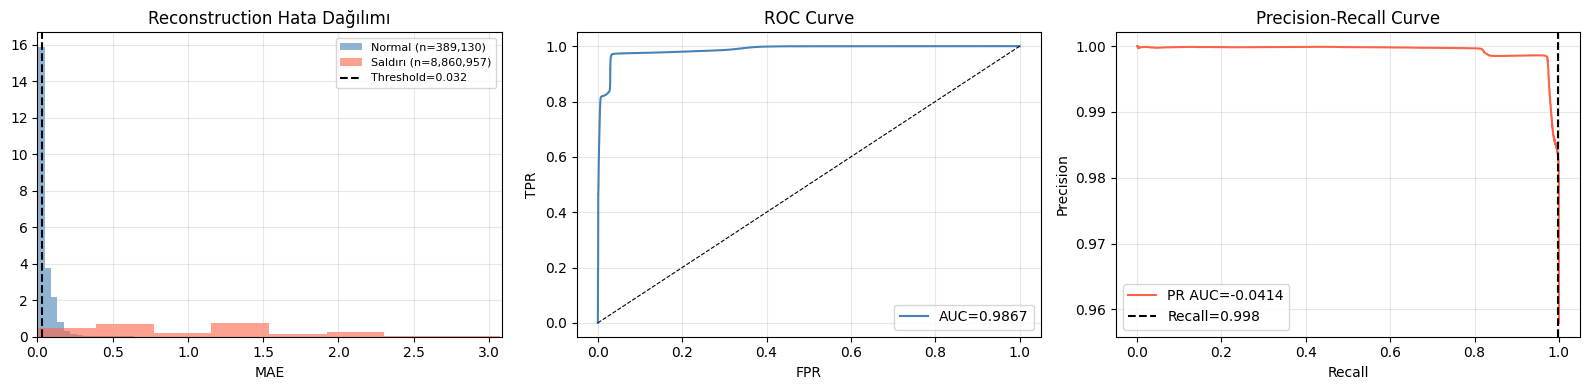

   -> Grafik kaydedildi: s5_eval_full.png

   📋 SUNUM ÖZETİ — SENARYO 5 BiLSTM-AE STUDENT (TAM VERİ)

  MİMARİ
  ├─ Teacher : MHA-LSTM (5.90 MB)
  ├─ Student : BiLSTM-AE (1.10 MB)
  ├─ İletişim Tasarrufu : %81.4
  ├─ Tamamlanan Round   : 51
  ├─ Best val_loss      : 0.02447
  └─ Alpha=0.3  |  Beta=0.7  |  Distillation: tüm sequence (B,20,64)

  TEST VERİSİ (DENGELEMESİZ)
  ├─ Normal  örnek :      389,130
  └─ Saldırı örnek :    8,860,957

  PERFORMANS — F1-OPTİMİZE (threshold=0.03165)
  ├─ Accuracy   : %98.175
  ├─ Precision  : %98.280
  ├─ Recall     : %99.842
  ├─ F1         : 0.9905
  ├─ ROC AUC    : 0.9867
  ├─ PR AUC     : -0.0414
  ├─ TP=8,846,952  FN=14,005
  └─ TN=234,287  FP=154,843

  PERFORMANS — 3-SIGMA (threshold=0.32050)
  ├─ Accuracy   : %82.511
  ├─ Precision  : %99.953
  ├─ Recall     : %81.782
  ├─ F1         : 0.8996
  ├─ TP=7,246,625  FN=1,614,332
  └─ TN=385,747  FP=3,383

  KULLANILAN THRESHOLD : 0.03165  (F1-Optimize)
  ├─ F1      : 0.9905
  ├─ Recall  : %99.842


In [ ]:
# =============================================================================
# SENARYO 5 — HÜCRE 8: TAM DENGESİZ VERİ DEĞERLENDİRMESİ
# =============================================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import pickle, os, gc, glob
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, precision_recall_curve, roc_curve
)
from tqdm.auto import tqdm

print("=" * 65)
print("   TAM DENGESİZ VERİ DEĞERLENDİRMESİ")
print("=" * 65)

# -----------------------------------------------------------------------------
# 0. DOSYA LİSTELERİ
# -----------------------------------------------------------------------------
all_attack_files = []
for root, dirs, files in os.walk('/content/drive/MyDrive/wifi_mqtt'):
    for file in files:
        if file.lower().endswith(".csv") and 'profiling' not in root.lower():
            all_attack_files.append(os.path.join(root, file))

print(f"✅ Saldırı dosyası: {len(all_attack_files)} adet")   # → 74 bekleniyor
print(f"✅ Normal dosyası : {len(all_benign_files)} adet")   # → 42 bekleniyor
# -----------------------------------------------------------------------------
# 1. EN İYİ AĞIRLIKLARI YÜKLE
# -----------------------------------------------------------------------------
student_model.set_weights(best_global_weights)
print(f"\n✅ Best ağırlıklar yüklendi (val_loss={best_global_val:.5f})")

# -----------------------------------------------------------------------------
# 2. RECONSTRUCTION HATA FONKSİYONU
# -----------------------------------------------------------------------------
def compute_errors_batched(file_list, label, batch_size=8192):
    errors = []
    for fpath in tqdm(file_list, desc=f"  {label}", leave=False):
        try:
            df = pd.read_csv(fpath)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            if len(df) < TIME_STEPS + 1:
                continue
            scaled = scaler.transform(df).astype(np.float32)
            pca_t  = pca.transform(scaled).astype(np.float32)
            n_seq  = len(pca_t) - TIME_STEPS
            seqs   = np.lib.stride_tricks.as_strided(
                pca_t,
                shape=(n_seq, TIME_STEPS, PCA_COMPONENTS),
                strides=(pca_t.strides[0], pca_t.strides[0], pca_t.strides[1])
            )
            seqs = np.array(seqs, dtype=np.float32)
            for i in range(0, len(seqs), batch_size):
                batch = tf.constant(seqs[i:i+batch_size])
                recon = student_model(batch, training=False)
                err   = tf.reduce_mean(
                    tf.abs(batch - tf.cast(recon, tf.float32)), axis=[1, 2]
                )
                errors.extend(err.numpy().tolist())
            del seqs, scaled, pca_t
        except Exception as e:
            print(f"    ⚠️ Atlandı: {os.path.basename(fpath)}: {e}")
    return np.array(errors, dtype=np.float32)

# -----------------------------------------------------------------------------
# 3. NORMAL VERİ
# -----------------------------------------------------------------------------
print("\n⏳ Normal veri reconstruction hatası hesaplanıyor...")
normal_errors = compute_errors_batched(all_benign_files, "Normal")
gc.collect()
print(f"   Normal örnek sayısı : {len(normal_errors):,}")
print(f"   Normal hata — mean={normal_errors.mean():.4f}, std={normal_errors.std():.4f}")

# -----------------------------------------------------------------------------
# 4. SALDIRI VERİSİ
# -----------------------------------------------------------------------------
print("\n⏳ Saldırı verisi reconstruction hatası hesaplanıyor...")
attack_errors = compute_errors_batched(all_attack_files, "Saldırı")
gc.collect()
print(f"   Saldırı örnek sayısı: {len(attack_errors):,}")
print(f"   Saldırı hata — mean={attack_errors.mean():.4f}, std={attack_errors.std():.4f}")

# -----------------------------------------------------------------------------
# 5. THRESHOLD OPTİMİZASYONU
# -----------------------------------------------------------------------------
print("\n🔍 Threshold optimizasyonu...")

all_errors = np.concatenate([normal_errors, attack_errors])
all_labels = np.concatenate([
    np.zeros(len(normal_errors), dtype=np.int8),
    np.ones(len(attack_errors),  dtype=np.int8)
])

auc_roc = roc_auc_score(all_labels, all_errors)
print(f"   ROC AUC: {auc_roc:.4f}")

precision_arr, recall_arr, thresh_arr = precision_recall_curve(all_labels, all_errors)
f1_arr = np.where(
    (precision_arr + recall_arr) > 0,
    2 * precision_arr * recall_arr / (precision_arr + recall_arr),
    0.0
)
best_f1_idx  = np.argmax(f1_arr)
threshold_f1 = float(thresh_arr[best_f1_idx])
best_f1      = f1_arr[best_f1_idx]
auc_pr       = np.trapz(recall_arr[::-1], precision_arr[::-1])

print(f"   F1-optimize threshold : {threshold_f1:.5f}")
print(f"   Bu threshold'daki F1  : {best_f1:.4f}")
print(f"   PR AUC                : {auc_pr:.4f}")

# -----------------------------------------------------------------------------
# 6. PERFORMANS METRİKLERİ
# -----------------------------------------------------------------------------
print("\n📊 Performans metrikleri:")

def evaluate_threshold(errors, labels, threshold, label=""):
    preds = (errors >= threshold).astype(np.int8)
    cm    = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1   = f1_score(labels, preds, zero_division=0)
    acc  = (tp + tn) / len(labels)
    print(f"\n  [{label}] threshold={threshold:.5f}")
    print(f"   Accuracy  : %{acc*100:.3f}")
    print(f"   Precision : %{prec*100:.3f}")
    print(f"   Recall    : %{rec*100:.3f}")
    print(f"   F1        : {f1:.4f}")
    print(f"   ROC AUC   : {auc_roc:.4f}")
    print(f"   TN={tn:,}  FP={fp:,}")
    print(f"   FN={fn:,}  TP={tp:,}")
    return {"threshold": threshold, "f1": f1, "precision": prec,
            "recall": rec, "auc": auc_roc, "tn": tn, "fp": fp,
            "fn": fn, "tp": tp, "acc": acc}

res_f1   = evaluate_threshold(all_errors, all_labels, threshold_f1, "F1-Optimize")

threshold_stat = float(normal_errors.mean() + 3 * normal_errors.std())
res_stat = evaluate_threshold(all_errors, all_labels, threshold_stat, "3-Sigma")

best_res       = res_f1 if res_f1["f1"] >= res_stat["f1"] else res_stat
best_threshold = best_res["threshold"]

print(f"\n🏆 Kullanılacak threshold: {best_threshold:.5f} (F1={best_res['f1']:.4f})")

THRESH_PATH = f"{SAVE_PATH}/s5_student_threshold.pkl"
with open(THRESH_PATH, 'wb') as f:
    pickle.dump(best_threshold, f)
print(f"✅ Threshold kaydedildi: {THRESH_PATH}")

# -----------------------------------------------------------------------------
# 7. GRAFİKLER
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(normal_errors, bins=100, alpha=0.6, color='steelblue',
             label=f'Normal (n={len(normal_errors):,})', density=True)
axes[0].hist(attack_errors, bins=100, alpha=0.6, color='tomato',
             label=f'Saldırı (n={len(attack_errors):,})', density=True)
axes[0].axvline(best_threshold, color='black', linestyle='--',
                label=f'Threshold={best_threshold:.3f}')
axes[0].set_xlim(0, np.percentile(attack_errors, 99))
axes[0].set_title("Reconstruction Hata Dağılımı")
axes[0].set_xlabel("MAE")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

fpr, tpr, _ = roc_curve(all_labels, all_errors)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=1.5,
             label=f'AUC={auc_roc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(recall_arr, precision_arr, color='tomato', linewidth=1.5,
             label=f'PR AUC={auc_pr:.4f}')
axes[2].axvline(best_res["recall"], color='black', linestyle='--',
                label=f'Recall={best_res["recall"]:.3f}')
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/s5_eval_full.png", dpi=100, bbox_inches='tight')
plt.show()
print("   -> Grafik kaydedildi: s5_eval_full.png")

# -----------------------------------------------------------------------------
# 8. SUNUM ÖZETİ (TAM DİNAMİK)
# -----------------------------------------------------------------------------
comm_saving  = (1 - student_model.count_params() / teacher_model.count_params()) * 100
total_rounds = len(history['round']) + 1

print(f"""
=================================================================
   📋 SUNUM ÖZETİ — SENARYO 5 BiLSTM-AE STUDENT (TAM VERİ)
=================================================================

  MİMARİ
  ├─ Teacher : MHA-LSTM ({teacher_model.count_params()*4/1e6:.2f} MB)
  ├─ Student : BiLSTM-AE ({student_model.count_params()*4/1e6:.2f} MB)
  ├─ İletişim Tasarrufu : %{comm_saving:.1f}
  ├─ Tamamlanan Round   : {total_rounds}
  ├─ Best val_loss      : {best_global_val:.5f}
  └─ Alpha={ALPHA}  |  Beta={BETA}  |  Distillation: tüm sequence (B,20,64)

  TEST VERİSİ (DENGELEMESİZ)
  ├─ Normal  örnek : {len(normal_errors):>12,}
  └─ Saldırı örnek : {len(attack_errors):>12,}

  PERFORMANS — F1-OPTİMİZE (threshold={res_f1['threshold']:.5f})
  ├─ Accuracy   : %{res_f1['acc']*100:.3f}
  ├─ Precision  : %{res_f1['precision']*100:.3f}
  ├─ Recall     : %{res_f1['recall']*100:.3f}
  ├─ F1         : {res_f1['f1']:.4f}
  ├─ ROC AUC    : {res_f1['auc']:.4f}
  ├─ PR AUC     : {auc_pr:.4f}
  ├─ TP={res_f1['tp']:,}  FN={res_f1['fn']:,}
  └─ TN={res_f1['tn']:,}  FP={res_f1['fp']:,}

  PERFORMANS — 3-SIGMA (threshold={res_stat['threshold']:.5f})
  ├─ Accuracy   : %{res_stat['acc']*100:.3f}
  ├─ Precision  : %{res_stat['precision']*100:.3f}
  ├─ Recall     : %{res_stat['recall']*100:.3f}
  ├─ F1         : {res_stat['f1']:.4f}
  ├─ TP={res_stat['tp']:,}  FN={res_stat['fn']:,}
  └─ TN={res_stat['tn']:,}  FP={res_stat['fp']:,}

  KULLANILAN THRESHOLD : {best_threshold:.5f}  ({('F1-Optimize' if best_res == res_f1 else '3-Sigma')})
  ├─ F1      : {best_res['f1']:.4f}
  ├─ Recall  : %{best_res['recall']*100:.3f}
  └─ FN      : {best_res['fn']:,}
=================================================================
""")

print("=" * 65)
print("   HÜCRE 8 TAMAMLANDI — HÜCRE 9'A GEÇEBİLİRSİNİZ")
print("=" * 65)

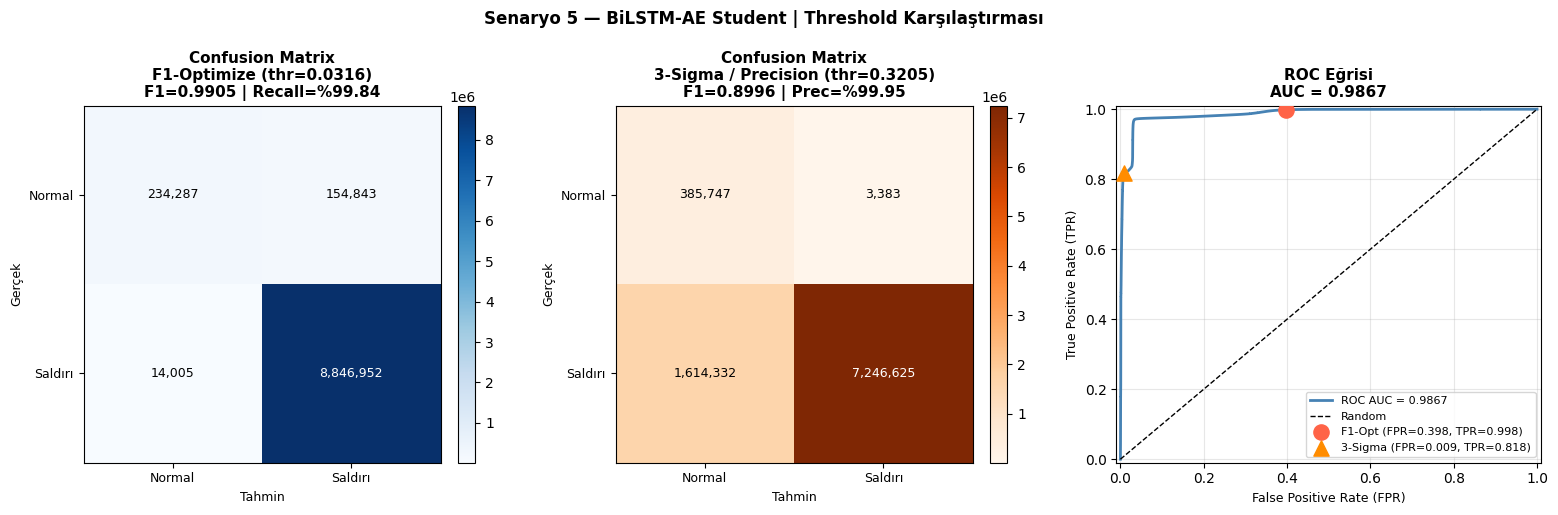

✅ Grafik kaydedildi: s5_cm_roc.png

┌─────────────────────┬──────────────────────┬──────────────────────┐
│ Metrik              │ F1-Optimize          │ 3-Sigma (Precision)  │
├─────────────────────┼──────────────────────┼──────────────────────┤
│ Threshold           │              0.03165 │              0.32050 │
│ Accuracy            │ %             98.175 │ %             82.511 │
│ Precision           │ %             98.280 │ %             99.953 │
│ Recall              │ %             99.842 │ %             81.782 │
│ F1                  │               0.9905 │               0.8996 │
│ ROC AUC             │               0.9867 │               0.9867 │
│ TP                  │            8,846,952 │            7,246,625 │
│ FN                  │               14,005 │            1,614,332 │
│ FP                  │              154,843 │                3,383 │
│ TN                  │              234,287 │              385,747 │
└─────────────────────┴──────────────────────┴────────

In [ ]:
# HÜCRE 8b — Confusion Matrix + ROC Eğrisi (Her İki Threshold)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
import itertools

def plot_cm(ax, cm, title, cmap='Blues'):
    classes = ['Normal', 'Saldırı']
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    tick_marks = [0, 1]
    ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=9)
    ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=9)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center', fontsize=9,
                color='white' if cm[i,j] > thresh else 'black')
    ax.set_ylabel('Gerçek', fontsize=9)
    ax.set_xlabel('Tahmin', fontsize=9)

# Confusion matrix verileri
cm_f1   = np.array([[res_f1['tn'],  res_f1['fp']],
                     [res_f1['fn'],  res_f1['tp']]])
cm_stat = np.array([[res_stat['tn'], res_stat['fp']],
                     [res_stat['fn'], res_stat['tp']]])

# ROC eğrisi
fpr, tpr, thresholds = roc_curve(all_labels, all_errors)
roc_auc_val = auc(fpr, tpr)

# threshold noktaları bul
idx_f1   = np.argmin(np.abs(thresholds - res_f1['threshold']))
idx_stat = np.argmin(np.abs(thresholds - res_stat['threshold']))

# ── PLOT ──
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Confusion Matrix — F1 Optimize
plot_cm(ax1, cm_f1,
        f'Confusion Matrix\nF1-Optimize (thr={res_f1["threshold"]:.4f})\n'
        f'F1={res_f1["f1"]:.4f} | Recall=%{res_f1["recall"]*100:.2f}')

# Confusion Matrix — 3-Sigma (Precision Odaklı)
plot_cm(ax2, cm_stat,
        f'Confusion Matrix\n3-Sigma / Precision (thr={res_stat["threshold"]:.4f})\n'
        f'F1={res_stat["f1"]:.4f} | Prec=%{res_stat["precision"]*100:.2f}',
        cmap='Oranges')

# ROC Eğrisi
ax3.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC AUC = {roc_auc_val:.4f}')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax3.scatter(fpr[idx_f1], tpr[idx_f1], s=120, zorder=5,
            color='tomato', marker='o',
            label=f'F1-Opt (FPR={fpr[idx_f1]:.3f}, TPR={tpr[idx_f1]:.3f})')
ax3.scatter(fpr[idx_stat], tpr[idx_stat], s=120, zorder=5,
            color='darkorange', marker='^',
            label=f'3-Sigma (FPR={fpr[idx_stat]:.3f}, TPR={tpr[idx_stat]:.3f})')
ax3.set_title(f'ROC Eğrisi\nAUC = {roc_auc_val:.4f}', fontsize=11, fontweight='bold')
ax3.set_xlabel('False Positive Rate (FPR)', fontsize=9)
ax3.set_ylabel('True Positive Rate (TPR)', fontsize=9)
ax3.legend(fontsize=8, loc='lower right')
ax3.grid(alpha=0.3)
ax3.set_xlim([-0.01, 1.01])
ax3.set_ylim([-0.01, 1.01])

plt.suptitle('Senaryo 5 — BiLSTM-AE Student | Threshold Karşılaştırması',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/s5_cm_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: s5_cm_roc.png")

# Özet tablo
print(f"""
┌─────────────────────┬──────────────────────┬──────────────────────┐
│ Metrik              │ F1-Optimize          │ 3-Sigma (Precision)  │
├─────────────────────┼──────────────────────┼──────────────────────┤
│ Threshold           │ {res_f1['threshold']:>20.5f} │ {res_stat['threshold']:>20.5f} │
│ Accuracy            │ %{res_f1['acc']*100:>19.3f} │ %{res_stat['acc']*100:>19.3f} │
│ Precision           │ %{res_f1['precision']*100:>19.3f} │ %{res_stat['precision']*100:>19.3f} │
│ Recall              │ %{res_f1['recall']*100:>19.3f} │ %{res_stat['recall']*100:>19.3f} │
│ F1                  │ {res_f1['f1']:>20.4f} │ {res_stat['f1']:>20.4f} │
│ ROC AUC             │ {res_f1['auc']:>20.4f} │ {res_stat['auc']:>20.4f} │
│ TP                  │ {res_f1['tp']:>20,} │ {res_stat['tp']:>20,} │
│ FN                  │ {res_f1['fn']:>20,} │ {res_stat['fn']:>20,} │
│ FP                  │ {res_f1['fp']:>20,} │ {res_stat['fp']:>20,} │
│ TN                  │ {res_f1['tn']:>20,} │ {res_stat['tn']:>20,} │
└─────────────────────┴──────────────────────┴──────────────────────┘
""")

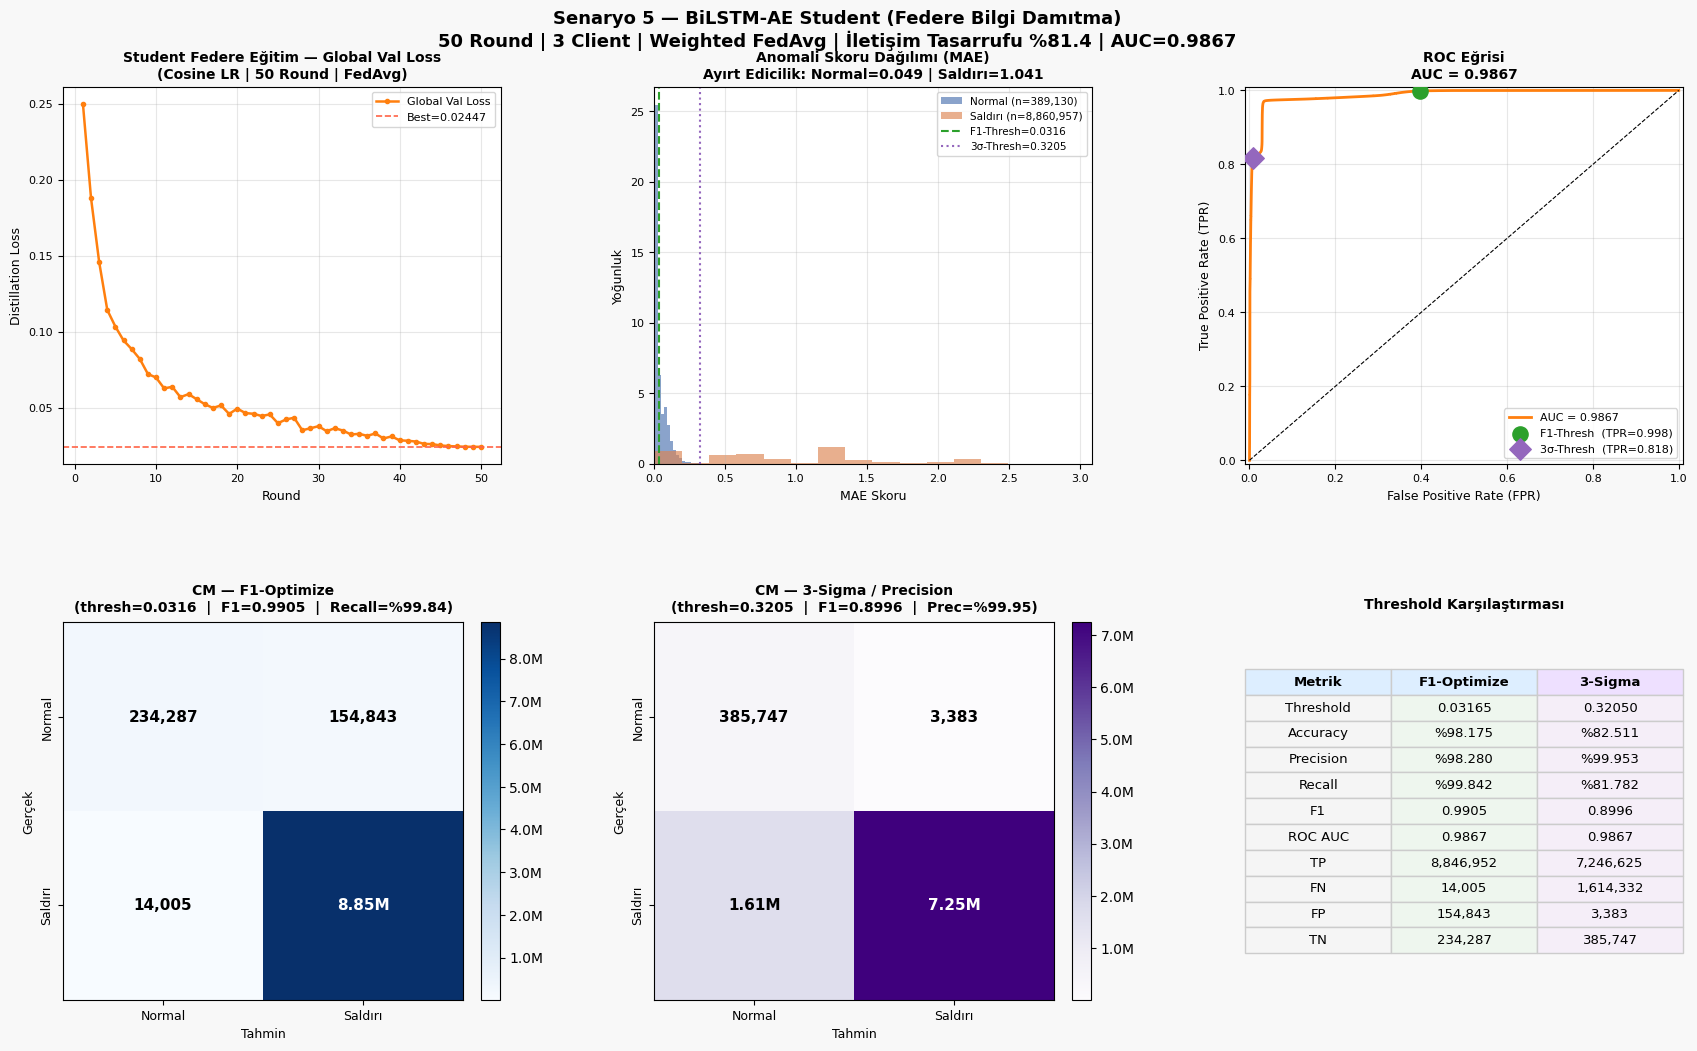

✅ Grafik kaydedildi: s5_student_sonuc_paneli_full.png


In [ ]:
# HÜCRE 8c — Teacher Paneli Formatında Kapsamlı Sonuç Paneli
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import itertools
from sklearn.metrics import roc_curve, auc

# ── Renkler ──────────────────────────────────────────────────────────────────
C_NORMAL  = '#4C72B0'
C_ATTACK  = '#DD8452'
C_F1      = '#2ca02c'
C_SIGMA   = '#9467bd'
C_ROC     = '#ff7f0e'

def draw_cm(ax, tn, fp, fn, tp, title, cmap):
    cm = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 format=lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}')
    for i, j in itertools.product(range(2), range(2)):
        val  = cm[i, j]
        txt  = f'{val/1e6:.2f}M' if val >= 1e6 else f'{val:,}'
        dark = cm[i, j] < cm.max() / 2
        ax.text(j, i, txt, ha='center', va='center', fontsize=11,
                fontweight='bold', color='black' if dark else 'white')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Normal', 'Saldırı'], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Normal', 'Saldırı'], fontsize=9,
                                                rotation=90, va='center')
    ax.set_xlabel('Tahmin', fontsize=9)
    ax.set_ylabel('Gerçek', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

# ── Eğitim history ────────────────────────────────────────────────────────────
rounds_hist = history['round']
vals_hist   = history['global_val']

# ── ROC ──────────────────────────────────────────────────────────────────────
fpr_r, tpr_r, thr_r = roc_curve(all_labels, all_errors)
auc_val = auc(fpr_r, tpr_r)
idx_f1_r   = np.argmin(np.abs(thr_r - res_f1['threshold']))
idx_sig_r  = np.argmin(np.abs(thr_r - res_stat['threshold']))

# ── Hata dağılımı percentile ──────────────────────────────────────────────────
xlim_max = float(np.percentile(attack_errors, 99))

# ─────────────────────────────────────────────────────────────────────────────
# LAYOUT: 2 satır × 3 sütun
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#F8F8F8')

gs = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.42, wspace=0.35,
                        left=0.07, right=0.97,
                        top=0.90, bottom=0.07)

ax_loss = fig.add_subplot(gs[0, 0])
ax_dist = fig.add_subplot(gs[0, 1])
ax_roc  = fig.add_subplot(gs[0, 2])
ax_cm1  = fig.add_subplot(gs[1, 0])
ax_cm2  = fig.add_subplot(gs[1, 1])
ax_tbl  = fig.add_subplot(gs[1, 2])

for ax in [ax_loss, ax_dist, ax_roc, ax_cm1, ax_cm2, ax_tbl]:
    ax.set_facecolor('white')

# ── 1. Eğitim Loss Grafiği ────────────────────────────────────────────────────
ax_loss.plot(rounds_hist, vals_hist, color=C_ROC, linewidth=1.8,
             marker='o', markersize=3, label='Global Val Loss')
ax_loss.axhline(best_global_val, color='tomato', linestyle='--', linewidth=1.2,
                label=f'Best={best_global_val:.5f}')
ax_loss.set_title('Student Federe Eğitim — Global Val Loss\n'
                  f'(Cosine LR | {len(rounds_hist)} Round | FedAvg)',
                  fontsize=10, fontweight='bold')
ax_loss.set_xlabel('Round', fontsize=9)
ax_loss.set_ylabel('Distillation Loss', fontsize=9)
ax_loss.legend(fontsize=8)
ax_loss.grid(alpha=0.3)
ax_loss.tick_params(labelsize=8)

# ── 2. Anomali Skoru Dağılımı ─────────────────────────────────────────────────
ax_dist.hist(normal_errors,  bins=200, alpha=0.65, color=C_NORMAL,
             label=f'Normal (n={len(normal_errors):,})', density=True)
ax_dist.hist(attack_errors,  bins=200, alpha=0.65, color=C_ATTACK,
             label=f'Saldırı (n={len(attack_errors):,})', density=True)
ax_dist.axvline(res_f1['threshold'],  color=C_F1,    linestyle='--',
                linewidth=1.5, label=f'F1-Thresh={res_f1["threshold"]:.4f}')
ax_dist.axvline(res_stat['threshold'], color=C_SIGMA, linestyle=':',
                linewidth=1.5, label=f'3σ-Thresh={res_stat["threshold"]:.4f}')
ax_dist.set_xlim(0, xlim_max)
ax_dist.set_title('Anomali Skoru Dağılımı (MAE)\n'
                  f'Ayırt Edicilik: Normal={normal_errors.mean():.3f} | '
                  f'Saldırı={attack_errors.mean():.3f}',
                  fontsize=10, fontweight='bold')
ax_dist.set_xlabel('MAE Skoru', fontsize=9)
ax_dist.set_ylabel('Yoğunluk', fontsize=9)
ax_dist.legend(fontsize=7.5)
ax_dist.grid(alpha=0.3)
ax_dist.tick_params(labelsize=8)

# ── 3. ROC Eğrisi ─────────────────────────────────────────────────────────────
ax_roc.plot(fpr_r, tpr_r, color=C_ROC, linewidth=2,
            label=f'AUC = {auc_val:.4f}')
ax_roc.plot([0,1],[0,1], 'k--', linewidth=0.8)
ax_roc.scatter(fpr_r[idx_f1_r],  tpr_r[idx_f1_r],  s=120, zorder=5,
               color=C_F1,    marker='o',
               label=f'F1-Thresh  (TPR={tpr_r[idx_f1_r]:.3f})')
ax_roc.scatter(fpr_r[idx_sig_r], tpr_r[idx_sig_r], s=120, zorder=5,
               color=C_SIGMA, marker='D',
               label=f'3σ-Thresh  (TPR={tpr_r[idx_sig_r]:.3f})')
ax_roc.set_title(f'ROC Eğrisi\nAUC = {auc_val:.4f}',
                 fontsize=10, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=9)
ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=9)
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.grid(alpha=0.3)
ax_roc.set_xlim([-0.01, 1.01]); ax_roc.set_ylim([-0.01, 1.01])
ax_roc.tick_params(labelsize=8)

# ── 4. Confusion Matrix — F1 Optimize ─────────────────────────────────────────
draw_cm(ax_cm1,
        tn=res_f1['tn'], fp=res_f1['fp'],
        fn=res_f1['fn'], tp=res_f1['tp'],
        title=(f'CM — F1-Optimize\n'
               f'(thresh={res_f1["threshold"]:.4f}  |  '
               f'F1={res_f1["f1"]:.4f}  |  Recall=%{res_f1["recall"]*100:.2f})'),
        cmap='Blues')

# ── 5. Confusion Matrix — 3-Sigma ─────────────────────────────────────────────
draw_cm(ax_cm2,
        tn=res_stat['tn'], fp=res_stat['fp'],
        fn=res_stat['fn'], tp=res_stat['tp'],
        title=(f'CM — 3-Sigma / Precision\n'
               f'(thresh={res_stat["threshold"]:.4f}  |  '
               f'F1={res_stat["f1"]:.4f}  |  Prec=%{res_stat["precision"]*100:.2f})'),
        cmap='Purples')

# ── 6. Özet Metrik Tablosu ────────────────────────────────────────────────────
ax_tbl.axis('off')
rows = [
    ['Metrik',          'F1-Optimize',
     f'3-Sigma'],
    ['Threshold',       f'{res_f1["threshold"]:.5f}',
     f'{res_stat["threshold"]:.5f}'],
    ['Accuracy',        f'%{res_f1["acc"]*100:.3f}',
     f'%{res_stat["acc"]*100:.3f}'],
    ['Precision',       f'%{res_f1["precision"]*100:.3f}',
     f'%{res_stat["precision"]*100:.3f}'],
    ['Recall',          f'%{res_f1["recall"]*100:.3f}',
     f'%{res_stat["recall"]*100:.3f}'],
    ['F1',              f'{res_f1["f1"]:.4f}',
     f'{res_stat["f1"]:.4f}'],
    ['ROC AUC',         f'{res_f1["auc"]:.4f}',
     f'{res_stat["auc"]:.4f}'],
    ['TP',              f'{res_f1["tp"]:,}',
     f'{res_stat["tp"]:,}'],
    ['FN',              f'{res_f1["fn"]:,}',
     f'{res_stat["fn"]:,}'],
    ['FP',              f'{res_f1["fp"]:,}',
     f'{res_stat["fp"]:,}'],
    ['TN',              f'{res_f1["tn"]:,}',
     f'{res_stat["tn"]:,}'],
]
col_colors = [['#DDEEFF', '#DDEEFF', '#EEE0FF']] + \
             [['#F5F5F5', '#EEF6EE', '#F5EEF8']] * (len(rows) - 1)

tbl = ax_tbl.table(
    cellText  = rows,
    cellLoc   = 'center',
    loc       = 'center',
    cellColours = col_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.55)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_text_props(fontweight='bold')
ax_tbl.set_title('Threshold Karşılaştırması', fontsize=10, fontweight='bold', pad=10)

# ── Başlık ────────────────────────────────────────────────────────────────────
comm_saving = (1 - student_model.count_params() / teacher_model.count_params()) * 100
fig.suptitle(
    f'Senaryo 5 — BiLSTM-AE Student (Federe Bilgi Damıtma)\n'
    f'{len(rounds_hist)} Round | 3 Client | Weighted FedAvg | '
    f'İletişim Tasarrufu %{comm_saving:.1f} | AUC={auc_val:.4f}',
    fontsize=13, fontweight='bold', y=0.97
)

plt.savefig(f'{SAVE_PATH}/s5_student_sonuc_paneli_full.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Grafik kaydedildi: s5_student_sonuc_paneli_full.png')


  [PR-Optimize] threshold=0.83406
   Accuracy  : %54.192
   Precision : %99.985
   Recall    : %52.188
   F1        : 0.6858
   ROC AUC   : 0.9867
   TN=388,426  FP=704
   FN=4,236,617  TP=4,624,340

PR-Optimize → threshold=0.83406 | Precision=%99.985 | Recall=%52.188 | F1=0.6858


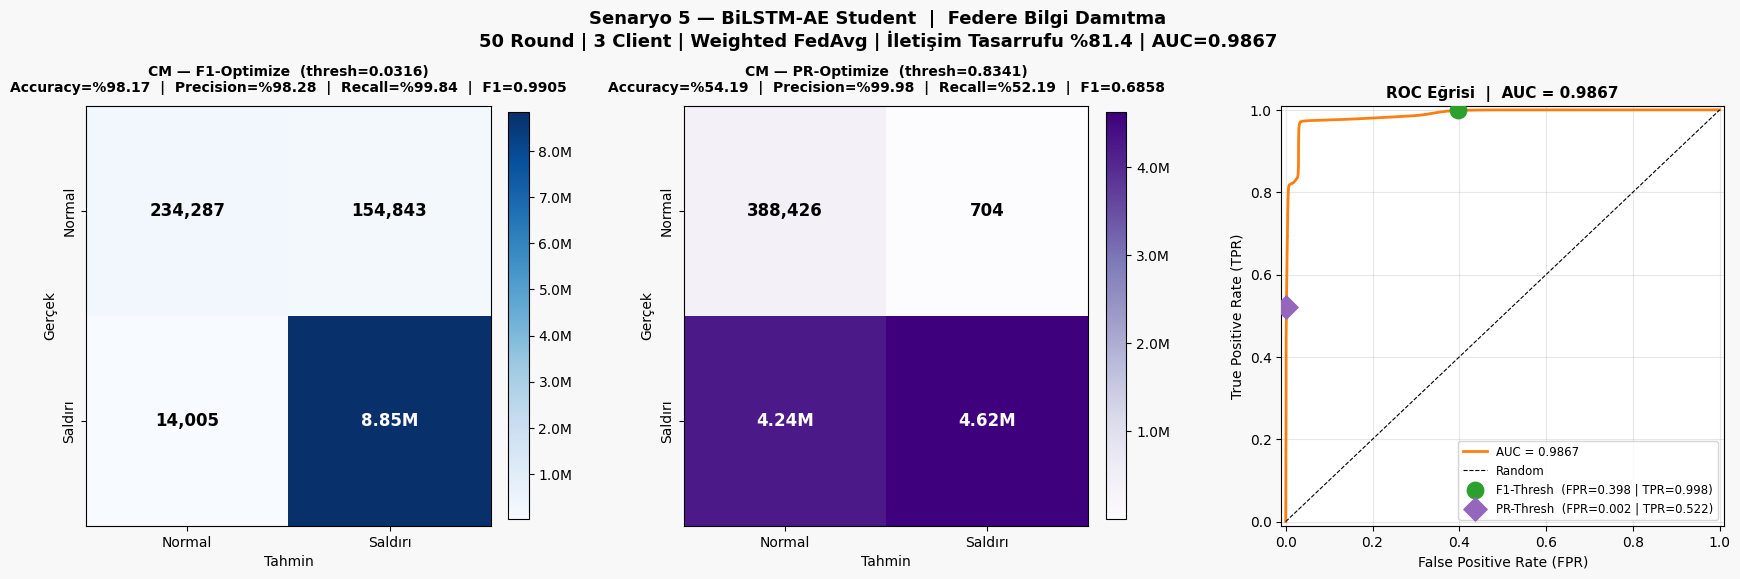

✅ Grafik kaydedildi: s5_cm_pr_roc.png

╔══════════════════════╦══════════════════════╦══════════════════════╗
║ Metrik               ║ F1-Optimize          ║ PR-Optimize          ║
╠══════════════════════╬══════════════════════╬══════════════════════╣
║ Threshold            ║              0.03165 ║              0.83406 ║
║ Accuracy             ║ %             98.175 ║ %             54.192 ║
║ Precision            ║ %             98.280 ║ %             99.985 ║
║ Recall               ║ %             99.842 ║ %             52.188 ║
║ F1                   ║               0.9905 ║               0.6858 ║
║ ROC AUC              ║               0.9867 ║               0.9867 ║
╠══════════════════════╬══════════════════════╬══════════════════════╣
║ TP                   ║            8,846,952 ║            4,624,340 ║
║ FN                   ║               14,005 ║            4,236,617 ║
║ FP                   ║              154,843 ║                  704 ║
║ TN                   ║              

In [ ]:
# HÜCRE 8d — PR-Optimize Threshold + Tam Panel (F1 | PR | ROC)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ── 1. PR-OPTİMİZE THRESHOLD ─────────────────────────────────────────────────
thresholds_scan = np.linspace(
    np.percentile(all_errors, 50),
    np.percentile(all_errors, 99.9),
    2000
)
best_thresh_pr, best_recall_pr = res_f1['threshold'], 0.0
for t in thresholds_scan:
    preds  = (all_errors >= t).astype(np.int8)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(all_labels, preds).ravel()
    prec_t = tp_t / (tp_t + fp_t + 1e-9)
    rec_t  = tp_t / (tp_t + fn_t + 1e-9)
    if prec_t >= 0.995 and rec_t > best_recall_pr:
        best_recall_pr = rec_t
        best_thresh_pr = t

res_pr = evaluate_threshold(all_errors, all_labels, best_thresh_pr, "PR-Optimize")
print(f"\nPR-Optimize → threshold={best_thresh_pr:.5f} | "
      f"Precision=%{res_pr['precision']*100:.3f} | "
      f"Recall=%{res_pr['recall']*100:.3f} | "
      f"F1={res_pr['f1']:.4f}")

# ── 2. PANEL ──────────────────────────────────────────────────────────────────
C_F1    = '#2ca02c'
C_PR    = '#9467bd'
C_ROC   = '#ff7f0e'

def draw_cm(ax, tn, fp, fn, tp, title, cmap):
    cm = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 format=lambda x, _: f'{x/1e6:.1f}M' if x>=1e6 else f'{int(x):,}')
    for i, j in itertools.product(range(2), range(2)):
        val = cm[i, j]
        txt = f'{val/1e6:.2f}M' if val >= 1e6 else f'{val:,}'
        ax.text(j, i, txt, ha='center', va='center', fontsize=12,
                fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Normal','Saldırı'], fontsize=10)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Normal','Saldırı'],
                                               fontsize=10, rotation=90, va='center')
    ax.set_xlabel('Tahmin', fontsize=10)
    ax.set_ylabel('Gerçek', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)

fpr_r, tpr_r, thr_r = roc_curve(all_labels, all_errors)
auc_val   = auc(fpr_r, tpr_r)
idx_f1_r  = np.argmin(np.abs(thr_r - res_f1['threshold']))
idx_pr_r  = np.argmin(np.abs(thr_r - best_thresh_pr))

fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#F8F8F8')
gs  = gridspec.GridSpec(1, 3, figure=fig,
                         hspace=0.3, wspace=0.35,
                         left=0.06, right=0.97,
                         top=0.82, bottom=0.12)

ax_cm1 = fig.add_subplot(gs[0])
ax_cm2 = fig.add_subplot(gs[1])
ax_roc = fig.add_subplot(gs[2])
for ax in [ax_cm1, ax_cm2, ax_roc]:
    ax.set_facecolor('white')

# CM — F1 Optimize
draw_cm(ax_cm1,
        tn=res_f1['tn'], fp=res_f1['fp'],
        fn=res_f1['fn'], tp=res_f1['tp'],
        title=(f'CM — F1-Optimize  (thresh={res_f1["threshold"]:.4f})\n'
               f'Accuracy=%{res_f1["acc"]*100:.2f}  |  '
               f'Precision=%{res_f1["precision"]*100:.2f}  |  '
               f'Recall=%{res_f1["recall"]*100:.2f}  |  F1={res_f1["f1"]:.4f}'),
        cmap='Blues')

# CM — PR Optimize
draw_cm(ax_cm2,
        tn=res_pr['tn'], fp=res_pr['fp'],
        fn=res_pr['fn'], tp=res_pr['tp'],
        title=(f'CM — PR-Optimize  (thresh={best_thresh_pr:.4f})\n'
               f'Accuracy=%{res_pr["acc"]*100:.2f}  |  '
               f'Precision=%{res_pr["precision"]*100:.2f}  |  '
               f'Recall=%{res_pr["recall"]*100:.2f}  |  F1={res_pr["f1"]:.4f}'),
        cmap='Purples')

# ROC
ax_roc.plot(fpr_r, tpr_r, color=C_ROC, linewidth=2,
            label=f'AUC = {auc_val:.4f}')
ax_roc.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
ax_roc.scatter(fpr_r[idx_f1_r], tpr_r[idx_f1_r], s=140, zorder=5,
               color=C_F1, marker='o',
               label=f'F1-Thresh  (FPR={fpr_r[idx_f1_r]:.3f} | TPR={tpr_r[idx_f1_r]:.3f})')
ax_roc.scatter(fpr_r[idx_pr_r], tpr_r[idx_pr_r], s=140, zorder=5,
               color=C_PR, marker='D',
               label=f'PR-Thresh  (FPR={fpr_r[idx_pr_r]:.3f} | TPR={tpr_r[idx_pr_r]:.3f})')
ax_roc.set_title(f'ROC Eğrisi  |  AUC = {auc_val:.4f}',
                 fontsize=11, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax_roc.legend(fontsize=8.5, loc='lower right')
ax_roc.grid(alpha=0.3)
ax_roc.set_xlim([-0.01,1.01]); ax_roc.set_ylim([-0.01,1.01])

comm_saving = (1 - student_model.count_params()/teacher_model.count_params())*100
fig.suptitle(
    f'Senaryo 5 — BiLSTM-AE Student  |  Federe Bilgi Damıtma\n'
    f'{len(history["round"])} Round | 3 Client | Weighted FedAvg | '
    f'İletişim Tasarrufu %{comm_saving:.1f} | AUC={auc_val:.4f}',
    fontsize=13, fontweight='bold', y=0.98
)

plt.savefig(f'{SAVE_PATH}/s5_cm_pr_roc.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Grafik kaydedildi: s5_cm_pr_roc.png')

# ── 3. DOĞRULUK ÖNEMLİLER ÖZETİ ─────────────────────────────────────────────
print(f"""
╔══════════════════════╦══════════════════════╦══════════════════════╗
║ Metrik               ║ F1-Optimize          ║ PR-Optimize          ║
╠══════════════════════╬══════════════════════╬══════════════════════╣
║ Threshold            ║ {res_f1['threshold']:>20.5f} ║ {best_thresh_pr:>20.5f} ║
║ Accuracy             ║ %{res_f1['acc']*100:>19.3f} ║ %{res_pr['acc']*100:>19.3f} ║
║ Precision            ║ %{res_f1['precision']*100:>19.3f} ║ %{res_pr['precision']*100:>19.3f} ║
║ Recall               ║ %{res_f1['recall']*100:>19.3f} ║ %{res_pr['recall']*100:>19.3f} ║
║ F1                   ║ {res_f1['f1']:>20.4f} ║ {res_pr['f1']:>20.4f} ║
║ ROC AUC              ║ {res_f1['auc']:>20.4f} ║ {res_pr['auc']:>20.4f} ║
╠══════════════════════╬══════════════════════╬══════════════════════╣
║ TP                   ║ {res_f1['tp']:>20,} ║ {res_pr['tp']:>20,} ║
║ FN                   ║ {res_f1['fn']:>20,} ║ {res_pr['fn']:>20,} ║
║ FP                   ║ {res_f1['fp']:>20,} ║ {res_pr['fp']:>20,} ║
║ TN                   ║ {res_f1['tn']:>20,} ║ {res_pr['tn']:>20,} ║
╚══════════════════════╩══════════════════════╩══════════════════════╝
""")

In [ ]:
# HÜCRE 9 — MODEL VE ARTEFAKTLARI KAYDET
import os, pickle, joblib
import tensorflow as tf

print("=" * 65)
print("   SENARYO 5 — MODEL KAYDETME")
print("=" * 65)

# En iyi ağırlıkları yükle (zaten yüklü ama garantiye alalım)
student_model.set_weights(best_global_weights)

# 1. Student model — tam model
student_model.save(f"{SAVE_PATH}/s5_student_bilstm_ae.keras")
print(f"✅ Student model (keras)  : s5_student_bilstm_ae.keras")

# 2. Student model — sadece ağırlıklar
student_model.save_weights(f"{SAVE_PATH}/s5_student_best.weights.h5")
print(f"✅ Student ağırlıklar (h5): s5_student_best.weights.h5")

# 3. Student encoder
student_encoder.save(f"{SAVE_PATH}/s5_student_encoder.keras")
print(f"✅ Student encoder        : s5_student_encoder.keras")

# 4. Threshold (F1-Optimize)
with open(f"{SAVE_PATH}/s5_threshold_f1.pkl", 'wb') as f:
    pickle.dump(res_f1['threshold'], f)
print(f"✅ Threshold F1-Opt       : {res_f1['threshold']:.5f}")

# 5. Threshold (PR-Optimize)
with open(f"{SAVE_PATH}/s5_threshold_pr.pkl", 'wb') as f:
    pickle.dump(best_thresh_pr, f)
print(f"✅ Threshold PR-Opt       : {best_thresh_pr:.5f}")

# 6. Scaler + PCA
joblib.dump(scaler, f"{SAVE_PATH}/s5_scaler.pkl")
joblib.dump(pca,    f"{SAVE_PATH}/s5_pca.pkl")
print(f"✅ Scaler + PCA kaydedildi")

# 7. Eğitim geçmişi
history_save = {
    "rounds"      : history["round"],
    "global_val"  : history["global_val"],
    "lr"          : history["lr"],
    "best_val"    : best_global_val,
    "alpha"       : ALPHA,
    "beta"        : BETA,
    "rounds_total": ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
}
with open(f"{SAVE_PATH}/s5_training_history.pkl", 'wb') as f:
    pickle.dump(history_save, f)
print(f"✅ Eğitim geçmişi kaydedildi")

# 8. Performans metrikleri
metrics_save = {
    "f1_optimize" : res_f1,
    "pr_optimize" : res_pr,
    "auc_roc"     : auc_val,
    "normal_mean" : float(normal_errors.mean()),
    "normal_std"  : float(normal_errors.std()),
    "attack_mean" : float(attack_errors.mean()),
    "attack_std"  : float(attack_errors.std()),
    "n_normal"    : len(normal_errors),
    "n_attack"    : len(attack_errors),
}
with open(f"{SAVE_PATH}/s5_metrics.pkl", 'wb') as f:
    pickle.dump(metrics_save, f)
print(f"✅ Metrikler kaydedildi")

# Özet
print(f"""
=================================================================
   KAYDEDILEN DOSYALAR → {SAVE_PATH}
=================================================================
   s5_student_bilstm_ae.keras     ← tam model
   s5_student_best.weights.h5     ← ağırlıklar
   s5_student_encoder.keras       ← encoder
   s5_threshold_f1.pkl            ← threshold (F1)
   s5_threshold_pr.pkl            ← threshold (PR)
   s5_scaler.pkl                  ← scaler
   s5_pca.pkl                     ← PCA
   s5_training_history.pkl        ← eğitim geçmişi
   s5_metrics.pkl                 ← performans metrikleri
   s5_student_best.weights.h5     ← (eğitim sırasında kaydedildi)
   s5_training_curve.png          ← eğitim grafiği
   s5_eval_full.png               ← değerlendirme grafiği
   s5_cm_pr_roc.png               ← CM + ROC paneli
=================================================================
""")
print("✅ HÜCRE 9 TAMAMLANDI")

   SENARYO 5 — MODEL KAYDETME
✅ Student model (keras)  : s5_student_bilstm_ae.keras
✅ Student ağırlıklar (h5): s5_student_best.weights.h5
✅ Student encoder        : s5_student_encoder.keras
✅ Threshold F1-Opt       : 0.03165
✅ Threshold PR-Opt       : 0.83406
✅ Scaler + PCA kaydedildi
✅ Eğitim geçmişi kaydedildi
✅ Metrikler kaydedildi

   KAYDEDILEN DOSYALAR → /content/drive/MyDrive/federe_s5_student_outputs
   s5_student_bilstm_ae.keras     ← tam model
   s5_student_best.weights.h5     ← ağırlıklar
   s5_student_encoder.keras       ← encoder
   s5_threshold_f1.pkl            ← threshold (F1)
   s5_threshold_pr.pkl            ← threshold (PR)
   s5_scaler.pkl                  ← scaler
   s5_pca.pkl                     ← PCA
   s5_training_history.pkl        ← eğitim geçmişi
   s5_metrics.pkl                 ← performans metrikleri
   s5_student_best.weights.h5     ← (eğitim sırasında kaydedildi)
   s5_training_curve.png          ← eğitim grafiği
   s5_eval_full.png               ← değe

   SENARYO 5 — XAI: SHAP ANALİZİ (Student Model)
✅ Background örnekleri : 100
⏳ Yüksek anomali skorlu saldırı örnekleri hazırlanıyor...
✅ Açıklanan örnekler   : 50
✅ Özellik boyutu (flat): 400

⏳ SHAP KernelExplainer başlatılıyor (~2-4 dk)...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ SHAP tamamlandı | shap_values shape: (50, 400)


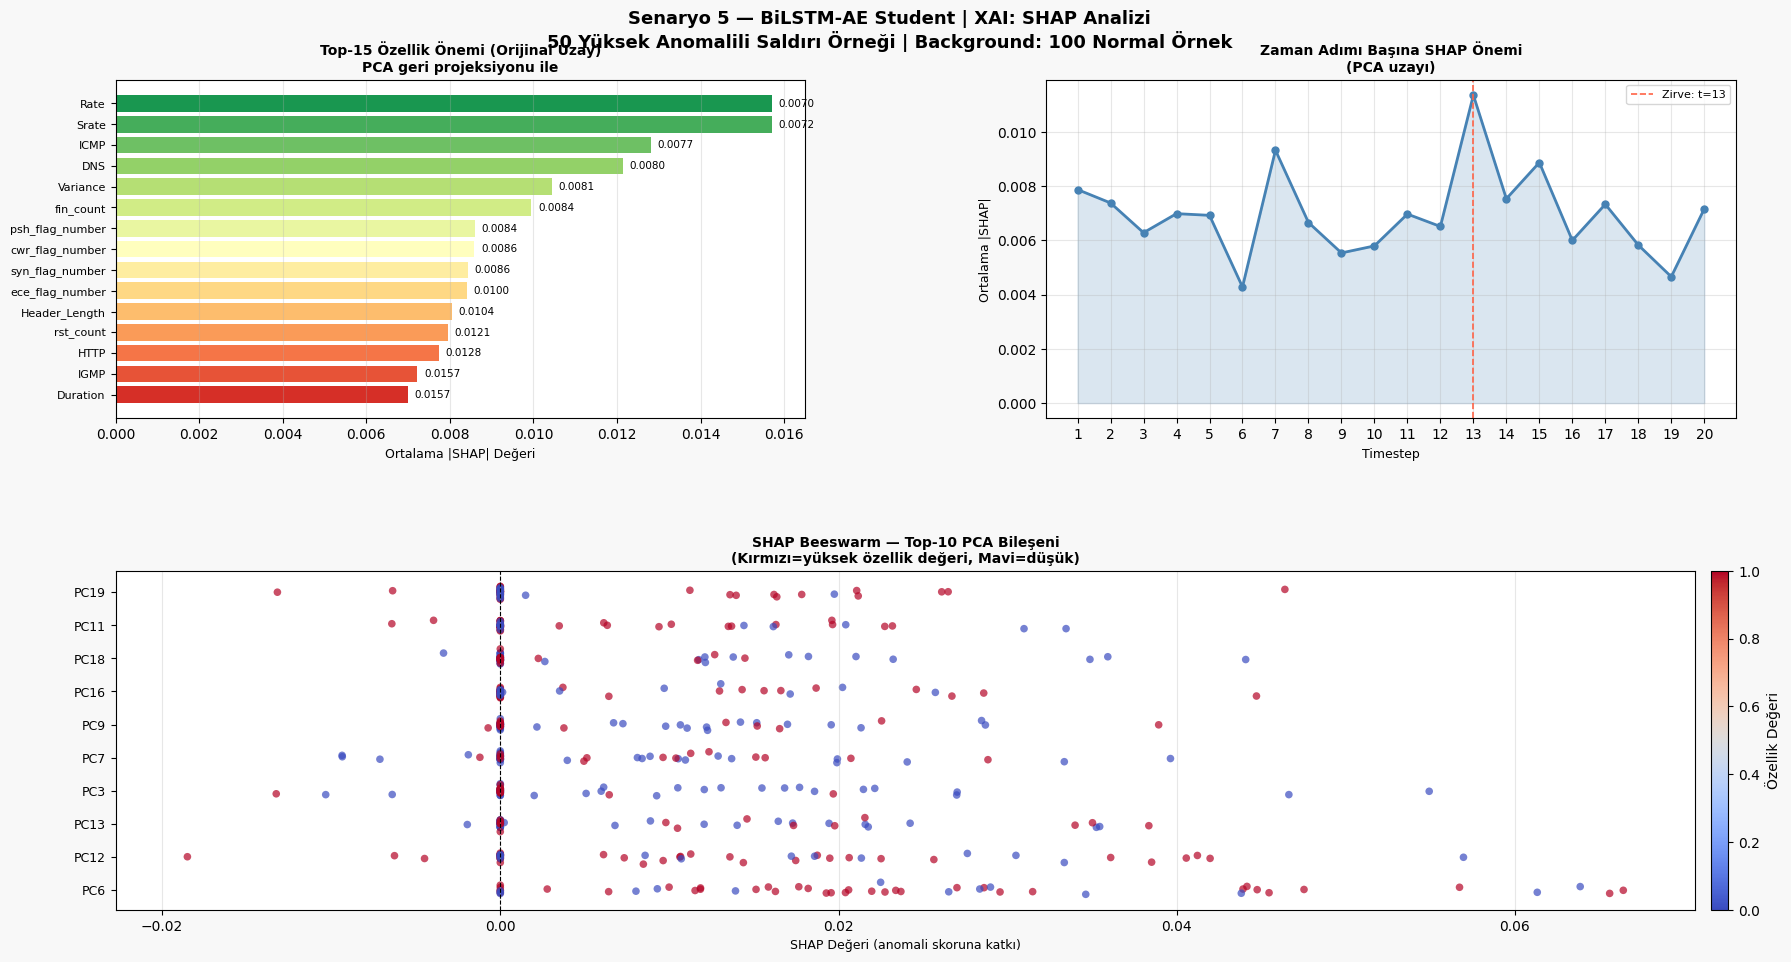

✅ SHAP grafiği kaydedildi: s5_shap_analiz.png

📋 En Önemli 10 Özellik (Anomali Tespiti İçin):
    1. Rate                                |SHAP|=0.01571
    2. Srate                               |SHAP|=0.01571
    3. ICMP                                |SHAP|=0.01281
    4. DNS                                 |SHAP|=0.01214
    5. Variance                            |SHAP|=0.01043
    6. fin_count                           |SHAP|=0.00995
    7. psh_flag_number                     |SHAP|=0.00860
    8. cwr_flag_number                     |SHAP|=0.00859
    9. syn_flag_number                     |SHAP|=0.00844
   10. ece_flag_number                     |SHAP|=0.00840

📋 En Kritik Zaman Adımı: t=13 (SHAP=0.01136)

   HÜCRE 10 TAMAMLANDI


In [ ]:
# HÜCRE 10 — XAI: SHAP ANALİZİ (BiLSTM-AE Student)
import shap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gc

print("=" * 65)
print("   SENARYO 5 — XAI: SHAP ANALİZİ (Student Model)")
print("=" * 65)

# -----------------------------------------------------------------------------
# 1. SHAP İÇİN SARMALAYICI
# -----------------------------------------------------------------------------
def student_anomaly_score_flat(X_flat):
    X_seq  = X_flat.reshape(-1, TIME_STEPS, PCA_COMPONENTS).astype(np.float32)
    recon  = student_model.predict(X_seq, batch_size=512, verbose=0)
    errors = np.mean(np.abs(X_seq - recon), axis=(1, 2))
    return errors

# -----------------------------------------------------------------------------
# 2. BACKGROUND — Normal veriden 100 örnek
# -----------------------------------------------------------------------------
np.random.seed(SEED)

try:
    X_bg_pool = np.concatenate([X_val1, X_val2, X_val3], axis=0)
except NameError:
    print("⚠️  X_val dizileri bellekte yok, normal dosyalardan örnekleniyor...")
    import pandas as pd
    _dfs = []
    for f in all_benign_files[:5]:
        df = pd.read_csv(f)
        df = df.select_dtypes(include=[np.number]).astype('float32')
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)
        for col in set(FEATURE_COLUMNS) - set(df.columns):
            df[col] = 0.0
        _dfs.append(df[FEATURE_COLUMNS])
    _df  = pd.concat(_dfs, ignore_index=True)
    _sc  = scaler.transform(_df).astype(np.float32)
    _pca = pca.transform(_sc).astype(np.float32)
    n_seq = len(_pca) - TIME_STEPS
    X_bg_pool = np.lib.stride_tricks.as_strided(
        _pca,
        shape=(n_seq, TIME_STEPS, PCA_COMPONENTS),
        strides=(_pca.strides[0], _pca.strides[0], _pca.strides[1])
    ).copy()
    del _dfs, _df, _sc, _pca
    gc.collect()

bg_idx = np.random.choice(len(X_bg_pool), size=100, replace=False)
X_bg   = X_bg_pool[bg_idx].reshape(100, -1)
print(f"✅ Background örnekleri : {X_bg.shape[0]}")

# -----------------------------------------------------------------------------
# 3. SALDIRI ÖRNEKLERİ — En yüksek MAE'li 50 örnek
# -----------------------------------------------------------------------------
print("⏳ Yüksek anomali skorlu saldırı örnekleri hazırlanıyor...")
import pandas as pd
_attack_seqs = []
for f in all_attack_files[:10]:
    try:
        df = pd.read_csv(f)
        df = df.select_dtypes(include=[np.number]).astype('float32')
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)
        for col in set(FEATURE_COLUMNS) - set(df.columns):
            df[col] = 0.0
        df = df[FEATURE_COLUMNS]
        if len(df) < TIME_STEPS + 1:
            continue
        sc  = scaler.transform(df).astype(np.float32)
        pc  = pca.transform(sc).astype(np.float32)
        n   = len(pc) - TIME_STEPS
        seq = np.lib.stride_tricks.as_strided(
            pc,
            shape=(n, TIME_STEPS, PCA_COMPONENTS),
            strides=(pc.strides[0], pc.strides[0], pc.strides[1])
        ).copy()
        _attack_seqs.append(seq)
    except Exception as e:
        print(f"  ⚠️ Atlandı: {e}")

X_atk_pool = np.concatenate(_attack_seqs, axis=0)
del _attack_seqs; gc.collect()

# FİX: hem pool hem predict aynı subset
_subset    = X_atk_pool[:2000]
_scores    = np.mean(np.abs(
    _subset - student_model.predict(_subset, batch_size=512, verbose=0)
), axis=(1, 2))
top_idx    = np.argsort(_scores)[::-1][:50]
X_explain  = _subset[top_idx].reshape(50, -1)
del X_atk_pool, _subset; gc.collect()

print(f"✅ Açıklanan örnekler   : {X_explain.shape[0]}")
print(f"✅ Özellik boyutu (flat): {X_explain.shape[1]}")

# -----------------------------------------------------------------------------
# 4. SHAP KernelExplainer
# -----------------------------------------------------------------------------
print("\n⏳ SHAP KernelExplainer başlatılıyor (~2-4 dk)...")
explainer   = shap.KernelExplainer(student_anomaly_score_flat, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=100)
print(f"✅ SHAP tamamlandı | shap_values shape: {shap_values.shape}")

# -----------------------------------------------------------------------------
# 5. PCA → ORİJİNAL ÖZELLİK UZAYINA GERİ PROJEKSİYON
# -----------------------------------------------------------------------------
shap_3d   = shap_values.reshape(50, TIME_STEPS, PCA_COMPONENTS)
pca_comps = pca.components_                                      # (20, n_features)

shap_orig  = np.tensordot(shap_3d.mean(axis=1), pca_comps, axes=[[1],[0]])
mean_abs   = np.abs(shap_orig).mean(axis=0)

feature_names = FEATURE_COLUMNS
top_n         = 15
top_idx_feat  = np.argsort(mean_abs)[::-1][:top_n]
top_names     = [feature_names[i] for i in top_idx_feat]
top_vals      = mean_abs[top_idx_feat]

shap_time = np.abs(shap_3d).mean(axis=(0, 2))  # (TIME_STEPS,)

# -----------------------------------------------------------------------------
# 6. GRAFİKLER
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#F8F8F8')
gs  = gridspec.GridSpec(2, 2, figure=fig,
                         hspace=0.45, wspace=0.35,
                         left=0.07, right=0.97,
                         top=0.90, bottom=0.07)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('white')

# (1) Top-15 Özellik Önem
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, top_n))
bars   = ax1.barh(range(top_n)[::-1], top_vals, color=colors)
ax1.set_yticks(range(top_n)[::-1])
ax1.set_yticklabels(top_names, fontsize=8)
ax1.set_xlabel('Ortalama |SHAP| Değeri', fontsize=9)
ax1.set_title(f'Top-{top_n} Özellik Önemi (Orijinal Uzay)\nPCA geri projeksiyonu ile',
              fontsize=10, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_vals[::-1]):
    ax1.text(bar.get_width() + max(top_vals)*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7.5)

# (2) Zaman Boyutunda SHAP
ax2.plot(range(1, TIME_STEPS+1), shap_time,
         color='steelblue', linewidth=2, marker='o', markersize=5)
ax2.fill_between(range(1, TIME_STEPS+1), shap_time, alpha=0.2, color='steelblue')
ax2.set_xlabel('Timestep', fontsize=9)
ax2.set_ylabel('Ortalama |SHAP|', fontsize=9)
ax2.set_title('Zaman Adımı Başına SHAP Önemi\n(PCA uzayı)',
              fontsize=10, fontweight='bold')
ax2.set_xticks(range(1, TIME_STEPS+1))
ax2.grid(alpha=0.3)
peak_t = int(np.argmax(shap_time))
ax2.axvline(peak_t+1, color='tomato', linestyle='--', linewidth=1.2,
            label=f'Zirve: t={peak_t+1}')
ax2.legend(fontsize=8)

# (3) SHAP Beeswarm (Top-10 PCA bileşeni)
pca_names  = [f'PC{i+1}' for i in range(PCA_COMPONENTS)]
shap_pca   = shap_3d.mean(axis=1)
top_pc_idx = np.argsort(np.abs(shap_pca).mean(axis=0))[::-1][:10]
shap_top   = shap_pca[:, top_pc_idx]
feat_top   = X_explain.reshape(50, TIME_STEPS, PCA_COMPONENTS).mean(axis=1)[:, top_pc_idx]

for i in range(10):
    y_jitter = np.random.normal(i, 0.08, size=50)
    ax3.scatter(shap_top[:, i], y_jitter,
                c=feat_top[:, i], cmap='coolwarm',
                s=30, alpha=0.7, linewidths=0)

ax3.set_yticks(range(10))
ax3.set_yticklabels([pca_names[top_pc_idx[j]] for j in range(10)], fontsize=9)
ax3.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_xlabel('SHAP Değeri (anomali skoruna katkı)', fontsize=9)
ax3.set_title('SHAP Beeswarm — Top-10 PCA Bileşeni\n'
              '(Kırmızı=yüksek özellik değeri, Mavi=düşük)',
              fontsize=10, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
sm = plt.cm.ScalarMappable(cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax3, fraction=0.015, pad=0.01, label='Özellik Değeri')

fig.suptitle('Senaryo 5 — BiLSTM-AE Student | XAI: SHAP Analizi\n'
             f'50 Yüksek Anomalili Saldırı Örneği | Background: 100 Normal Örnek',
             fontsize=13, fontweight='bold', y=0.97)

plt.savefig(f'{SAVE_PATH}/s5_shap_analiz.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ SHAP grafiği kaydedildi: s5_shap_analiz.png')

# -----------------------------------------------------------------------------
# 7. ÖZET
# -----------------------------------------------------------------------------
print(f"\n📋 En Önemli 10 Özellik (Anomali Tespiti İçin):")
for rank, (name, val) in enumerate(zip(top_names[:10], top_vals[:10]), 1):
    print(f"   {rank:2d}. {name:<35} |SHAP|={val:.5f}")

print(f"\n📋 En Kritik Zaman Adımı: t={peak_t+1} (SHAP={shap_time[peak_t]:.5f})")
print("\n" + "=" * 65)
print("   HÜCRE 10 TAMAMLANDI")
print("=" * 65)

# Yukarıdakı kotu yenisi asaggıda SHAP ın


   SENARYO 5 — XAI: SHAP ANALİZİ (Student Model)

🔍 En yüksek anomali skorlu saldırı paketi aranıyor...
   -> Kaynak dosya   : TCP_IP-DDoS-ICMP7_train.pcap.csv
   -> Anomali skoru  : 10.9602  (346.3x threshold)

⚡ SHAP KernelExplainer kuruluyor...
   -> Background: (100, 400)
⏳ Shapley değerleri hesaplanıyor (~2-3 dk)...


  0%|          | 0/1 [00:00<?, ?it/s]

✅ SHAP tamamlandı | shape: (1, 400)

⚡ Client bazlı özellik reconstruction error...
   -> WiFi: MAE=0.12457
   -> MQTT: MAE=0.02408
   -> Mixed: MAE=0.05632

📈 XAI paneli hazırlanıyor...


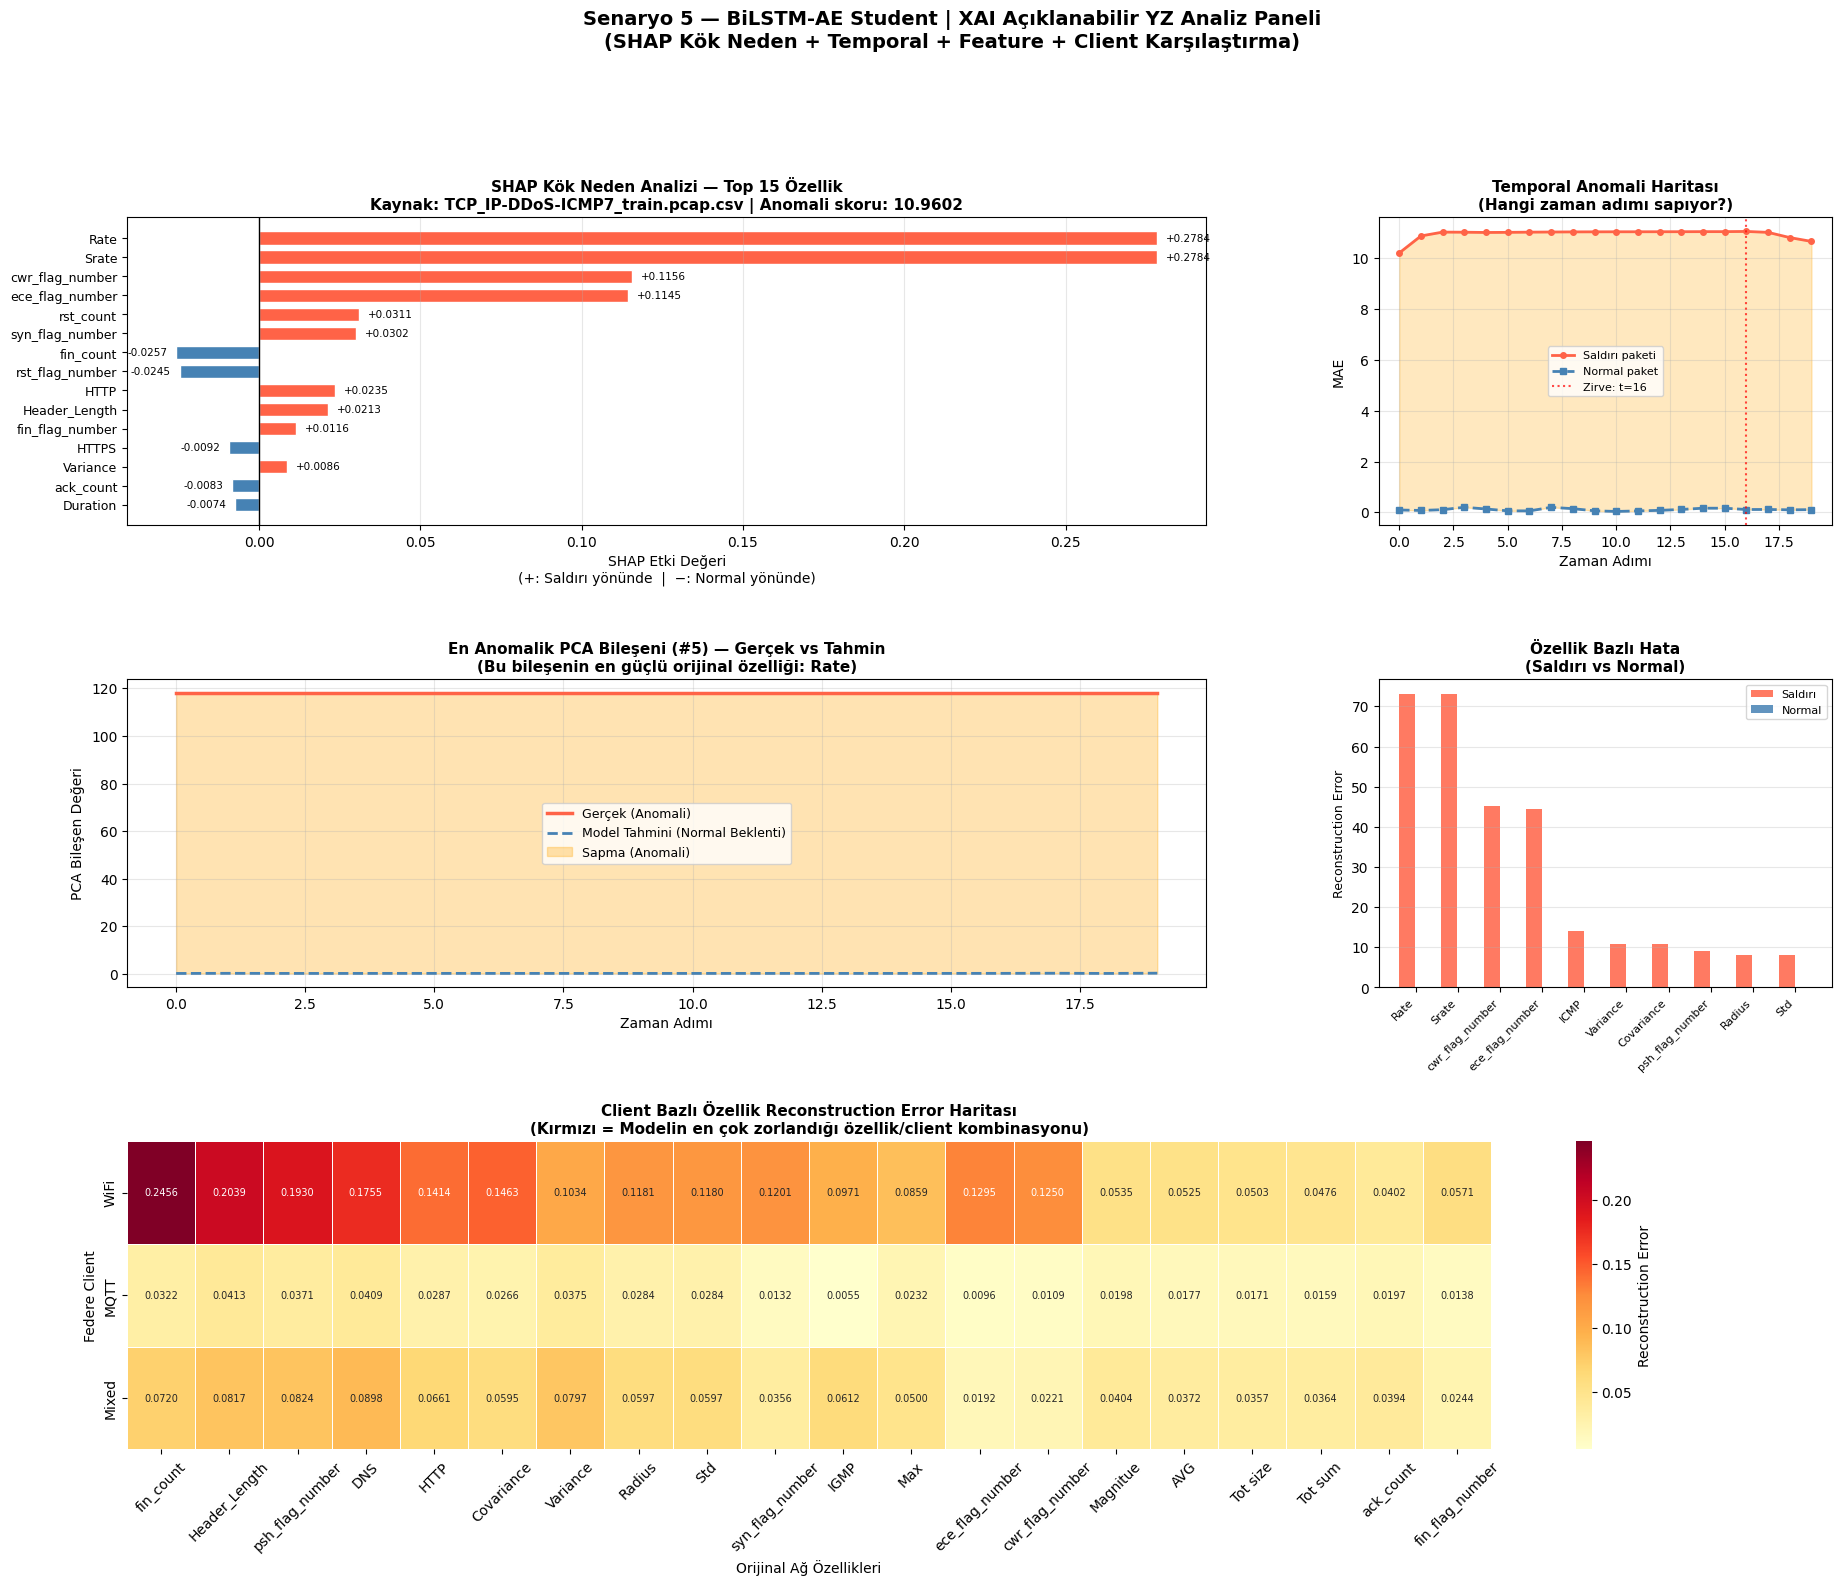

✅ Grafik kaydedildi: s5_shap_xai_panel.png

   📋 KÖK NEDEN RAPORU — EN ŞİDDETLİ SALDIRI PAKETİ
   Kaynak dosya       : TCP_IP-DDoS-ICMP7_train.pcap.csv
   Anomali skoru      : 10.9602  (threshold 0.03165'nin 346.3x üstünde)
   Zirve zaman adımı  : t=16 / 19

   Saldırıyı tetikleyen en önemli özellikler:
   Sıra  Özellik                         SHAP Değeri   Yön
   ────────────────────────────────────────────────────────────
   1     Rate                            +0.278443   ↑ Saldırı
   2     Srate                           +0.278443   ↑ Saldırı
   3     cwr_flag_number                 +0.115555   ↑ Saldırı
   4     ece_flag_number                 +0.114463   ↑ Saldırı
   5     rst_count                       +0.031102   ↑ Saldırı
   6     syn_flag_number                 +0.030165   ↑ Saldırı
   7     fin_count                       -0.025663   ↓ Normal
   8     rst_flag_number                 -0.024514   ↓ Normal
   9     HTTP                            +0.023474   ↑ Saldırı
   10  

In [ ]:
# HÜCRE 10 — XAI: SHAP ANALİZİ (BiLSTM-AE Student — Teacher formatı)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap, gc, os
import tensorflow as tf

print("=" * 65)
print("   SENARYO 5 — XAI: SHAP ANALİZİ (Student Model)")
print("=" * 65)

expected_cols = list(scaler.feature_names_in_)
DYNAMIC_THRESHOLD = res_f1['threshold']

# =============================================================================
# A1. EN YÜKSEK ANOMALI SKORLU SALDIRI PAKETİNİ BUL
# =============================================================================
print("\n🔍 En yüksek anomali skorlu saldırı paketi aranıyor...")

def create_sequences_fast(data, time_steps):
    n = data.shape[0] - time_steps
    shape   = (n, time_steps, data.shape[1])
    strides = (data.strides[0], data.strides[0], data.strides[1])
    return np.array(np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides),
                    dtype=np.float32)

best_score, best_seq, best_file, best_local_idx = 0, None, None, 0

for f in all_attack_files[:15]:
    try:
        df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
        df.replace([np.inf, -np.inf], np.nan, inplace=True); df.dropna(inplace=True)
        for col in set(expected_cols) - set(df.columns): df[col] = 0.0
        df = df[expected_cols]
        if len(df) <= TIME_STEPS: continue
        sc  = scaler.transform(df).astype(np.float32)
        pc  = pca.transform(sc).astype(np.float32)
        seqs = create_sequences_fast(pc, TIME_STEPS)
        preds = student_model.predict(seqs[:2000], batch_size=512, verbose=0)
        mae   = np.mean(np.abs(seqs[:2000] - preds), axis=(1,2))
        idx   = np.argmax(mae)
        if mae[idx] > best_score:
            best_score     = mae[idx]
            best_seq       = seqs[idx:idx+1]
            best_file      = f
            best_local_idx = idx
        del sc, pc, seqs, preds
    except Exception as e:
        print(f"  ⚠️ {os.path.basename(f)}: {e}")

print(f"   -> Kaynak dosya   : {os.path.basename(best_file)}")
print(f"   -> Anomali skoru  : {best_score:.4f}  ({best_score/DYNAMIC_THRESHOLD:.1f}x threshold)")

# =============================================================================
# A2. SHAP KernelExplainer
# =============================================================================
print("\n⚡ SHAP KernelExplainer kuruluyor...")

def predict_anomaly_score(X_flat):
    X_3d  = X_flat.reshape(-1, TIME_STEPS, PCA_COMPONENTS).astype(np.float32)
    preds = student_model.predict(X_3d, batch_size=256, verbose=0)
    return np.mean(np.abs(X_3d - preds), axis=(1, 2))

np.random.seed(SEED)
try:
    bg_pool = np.concatenate([X_val1, X_val2, X_val3], axis=0)
    bg_parts = []
    for split in np.array_split(bg_pool, 3):
        idx = np.random.choice(len(split), 34, replace=False)
        bg_parts.append(split[idx])
    bg_3d = np.concatenate(bg_parts, axis=0)[:100]
except NameError:
    _dfs = []
    for f in all_benign_files[:6]:
        df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
        df.replace([np.inf, -np.inf], np.nan, inplace=True); df.dropna(inplace=True)
        for col in set(expected_cols)-set(df.columns): df[col]=0.0
        _dfs.append(df[expected_cols])
    _df = pd.concat(_dfs); sc2 = scaler.transform(_df).astype(np.float32)
    pc2 = pca.transform(sc2).astype(np.float32)
    bg_pool = create_sequences_fast(pc2, TIME_STEPS)
    idx = np.random.choice(len(bg_pool), 100, replace=False)
    bg_3d = bg_pool[idx]; del _dfs,_df,sc2,pc2,bg_pool; gc.collect()

bg_flat      = bg_3d.reshape(100, -1)
anomaly_flat = best_seq.reshape(1, -1)

print(f"   -> Background: {bg_flat.shape}")
print("⏳ Shapley değerleri hesaplanıyor (~2-3 dk)...")
explainer   = shap.KernelExplainer(predict_anomaly_score, bg_flat)
shap_values = explainer.shap_values(anomaly_flat, nsamples=200)
print(f"✅ SHAP tamamlandı | shape: {np.array(shap_values).shape}")

# =============================================================================
# A3. PCA → ORİJİNAL ÖZELLİK UZAYINA GERİ PROJEKSİYON
# =============================================================================
shap_3d   = np.array(shap_values).reshape(TIME_STEPS, PCA_COMPONENTS)
shap_mean = np.mean(shap_3d, axis=0, keepdims=True)               # (1, 20)
orig_shap = np.dot(shap_mean, pca.components_)                     # (1, n_feat)
shap_scores_orig = orig_shap[0]
feature_names    = np.array(expected_cols)

top_n      = 15
top_idx    = np.argsort(np.abs(shap_scores_orig))[-top_n:][::-1]
top_names  = feature_names[top_idx]
top_shap   = shap_scores_orig[top_idx]
bar_colors = ['tomato' if s > 0 else 'steelblue' for s in top_shap]

# Temporal anomali
pred_anomaly = student_model.predict(best_seq, verbose=0)
pred_normal  = student_model.predict(bg_3d[:1], verbose=0)
temporal_mae_anomaly = np.mean(np.abs(best_seq[0]    - pred_anomaly[0]), axis=1)
temporal_mae_normal  = np.mean(np.abs(bg_3d[0]       - pred_normal[0]),  axis=1)

feature_mae_anomaly = np.mean(np.abs(best_seq[0] - pred_anomaly[0]), axis=0)
feature_mae_normal  = np.mean(np.abs(bg_3d[0]    - pred_normal[0]),  axis=0)
feat_err_anomaly = np.dot(feature_mae_anomaly.reshape(1,-1), pca.components_)[0]
feat_err_normal  = np.dot(feature_mae_normal.reshape(1,-1),  pca.components_)[0]

# =============================================================================
# B. CLIENT BAZLI ÖZELLIK HATA HARİTASI
# =============================================================================
print("\n⚡ Client bazlı özellik reconstruction error...")

client_feature_errors = {}
for ds_val, cname in zip([val_ds1, val_ds2, val_ds3], ['WiFi', 'MQTT', 'Mixed']):
    all_x = np.concatenate([x.numpy() for x, _ in ds_val], axis=0)
    idx   = np.random.choice(len(all_x), min(500, len(all_x)), replace=False)
    samp  = all_x[idx]
    preds = student_model.predict(samp, batch_size=256, verbose=0)
    feat_err_pca  = np.mean(np.abs(samp - preds), axis=(0, 1))
    feat_err_orig = np.dot(feat_err_pca.reshape(1,-1), pca.components_)[0]
    client_feature_errors[cname] = feat_err_orig
    print(f"   -> {cname}: MAE={np.mean(feat_err_pca):.5f}")
    del all_x, samp, preds; gc.collect()

# =============================================================================
# GÖRSELLEŞTİRME — Teacher formatı 5 panel
# =============================================================================
print("\n📈 XAI paneli hazırlanıyor...")

fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

ax0 = fig.add_subplot(gs[0, :2])   # SHAP bar
ax1 = fig.add_subplot(gs[0, 2])    # Temporal
ax2 = fig.add_subplot(gs[1, :2])   # Gerçek vs Tahmin
ax3 = fig.add_subplot(gs[1, 2])    # Feature bazlı hata
ax4 = fig.add_subplot(gs[2, :])    # Client heatmap

# ── (1) SHAP Bar ─────────────────────────────────────────────────────────────
bars = ax0.barh(range(top_n), top_shap[::-1],
                color=bar_colors[::-1], edgecolor='white', height=0.7)
ax0.set_yticks(range(top_n))
ax0.set_yticklabels(top_names[::-1], fontsize=9)
ax0.axvline(0, color='black', linewidth=1)
ax0.set_xlabel('SHAP Etki Değeri\n(+: Saldırı yönünde  |  −: Normal yönünde)', fontsize=10)
ax0.set_title(
    f'SHAP Kök Neden Analizi — Top {top_n} Özellik\n'
    f'Kaynak: {os.path.basename(best_file)} | '
    f'Anomali skoru: {best_score:.4f}',
    fontsize=11, fontweight='bold')
ax0.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_shap[::-1]):
    ax0.text(val + (max(np.abs(top_shap))*0.01 if val >= 0 else -max(np.abs(top_shap))*0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:+.4f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=7.5)

# ── (2) Temporal Anomali ──────────────────────────────────────────────────────
peak_t = int(np.argmax(temporal_mae_anomaly))
ax1.plot(range(TIME_STEPS), temporal_mae_anomaly,
         color='tomato', linewidth=2, marker='o', markersize=4, label='Saldırı paketi')
ax1.plot(range(TIME_STEPS), temporal_mae_normal,
         color='steelblue', linewidth=2, linestyle='--', marker='s', markersize=4,
         label='Normal paket')
ax1.fill_between(range(TIME_STEPS), temporal_mae_anomaly, temporal_mae_normal,
                 alpha=0.25, color='orange')
ax1.axvline(peak_t, color='red', linestyle=':', alpha=0.7, label=f'Zirve: t={peak_t}')
ax1.set_xlabel('Zaman Adımı', fontsize=10)
ax1.set_ylabel('MAE', fontsize=10)
ax1.set_title('Temporal Anomali Haritası\n(Hangi zaman adımı sapıyor?)',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ── (3) Gerçek vs Tahmin ──────────────────────────────────────────────────────
top1_pca = int(np.argmax(np.abs(shap_mean[0])))
top1_feat = feature_names[np.argmax(np.abs(pca.components_[top1_pca]))]
ax2.plot(best_seq[0, :, top1_pca], color='tomato', linewidth=2.5,
         label='Gerçek (Anomali)')
ax2.plot(pred_anomaly[0, :, top1_pca], color='steelblue', linewidth=2,
         linestyle='--', label='Model Tahmini (Normal Beklenti)')
ax2.fill_between(range(TIME_STEPS),
                 best_seq[0, :, top1_pca], pred_anomaly[0, :, top1_pca],
                 alpha=0.3, color='orange', label='Sapma (Anomali)')
ax2.set_xlabel('Zaman Adımı', fontsize=10)
ax2.set_ylabel('PCA Bileşen Değeri', fontsize=10)
ax2.set_title(
    f'En Anomalik PCA Bileşeni (#{top1_pca}) — Gerçek vs Tahmin\n'
    f'(Bu bileşenin en güçlü orijinal özelliği: {top1_feat})',
    fontsize=11, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# ── (4) Feature Bazlı Hata ───────────────────────────────────────────────────
top_feat_idx   = np.argsort(feat_err_anomaly)[-10:][::-1]
top_feat_names = feature_names[top_feat_idx]
x_pos = np.arange(len(top_feat_idx))
ax3.bar(x_pos-0.2, feat_err_anomaly[top_feat_idx], width=0.38,
        color='tomato', alpha=0.85, label='Saldırı')
ax3.bar(x_pos+0.2, feat_err_normal[top_feat_idx],  width=0.38,
        color='steelblue', alpha=0.85, label='Normal')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(top_feat_names, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Reconstruction Error', fontsize=9)
ax3.set_title('Özellik Bazlı Hata\n(Saldırı vs Normal)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# ── (5) Client Heatmap ───────────────────────────────────────────────────────
all_errs  = np.stack(list(client_feature_errors.values()), axis=0)
top20_idx = np.argsort(np.mean(all_errs, axis=0))[-20:][::-1]
heatmap_data = pd.DataFrame(
    all_errs[:, top20_idx],
    index=['WiFi', 'MQTT', 'Mixed'],
    columns=feature_names[top20_idx]
)
sns.heatmap(heatmap_data, ax=ax4, cmap='YlOrRd',
            annot=True, fmt='.4f', annot_kws={'size': 7},
            linewidths=0.5, cbar_kws={'label': 'Reconstruction Error'})
ax4.set_title(
    'Client Bazlı Özellik Reconstruction Error Haritası\n'
    '(Kırmızı = Modelin en çok zorlandığı özellik/client kombinasyonu)',
    fontsize=11, fontweight='bold')
ax4.set_xlabel('Orijinal Ağ Özellikleri', fontsize=10)
ax4.set_ylabel('Federe Client', fontsize=10)
ax4.tick_params(axis='x', rotation=45)

fig.suptitle(
    'Senaryo 5 — BiLSTM-AE Student | XAI Açıklanabilir YZ Analiz Paneli\n'
    '(SHAP Kök Neden + Temporal + Feature + Client Karşılaştırma)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig(f'{SAVE_PATH}/s5_shap_xai_panel.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Grafik kaydedildi: s5_shap_xai_panel.png")

# =============================================================================
# KÖK NEDEN RAPORU
# =============================================================================
print(f"""
{'='*65}
   📋 KÖK NEDEN RAPORU — EN ŞİDDETLİ SALDIRI PAKETİ
{'='*65}
   Kaynak dosya       : {os.path.basename(best_file)}
   Anomali skoru      : {best_score:.4f}  (threshold {DYNAMIC_THRESHOLD:.5f}'nin {best_score/DYNAMIC_THRESHOLD:.1f}x üstünde)
   Zirve zaman adımı  : t={peak_t} / {TIME_STEPS-1}

   Saldırıyı tetikleyen en önemli özellikler:
   {'Sıra':<5} {'Özellik':<28} {'SHAP Değeri':>14}   Yön""")
print(f"   {'─'*60}")
for i, (name, score) in enumerate(zip(top_names, top_shap)):
    print(f"   {i+1:<5} {name:<28} {score:>+12.6f}   {'↑ Saldırı' if score>0 else '↓ Normal'}")

print(f"\n{'='*65}")
print("   HÜCRE 10 TAMAMLANDI")
print(f"{'='*65}")

In [ ]:
# KAPANMADAN ÖNCE — KAYIT DOĞRULAMA
import os

print("=" * 65)
print("   DRIVE KAYIT DOĞRULAMA")
print("=" * 65)

beklenen = [
    "s5_student_bilstm_ae.keras",
    "s5_student_best.weights.h5",
    "s5_student_encoder.keras",
    "s5_threshold_f1.pkl",
    "s5_threshold_pr.pkl",
    "s5_scaler.pkl",
    "s5_pca.pkl",
    "s5_training_history.pkl",
    "s5_metrics.pkl",
    "s5_training_curve.png",
    "s5_eval_full.png",
    "s5_cm_pr_roc.png",
    "s5_shap_xai_panel.png",
]

for fname in beklenen:
    fpath = f"{SAVE_PATH}/{fname}"
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath)/1024 if exists else 0
    status = f"✅ {size:.1f} KB" if exists else "❌ EKSİK"
    print(f"   {status:>15}  {fname}")

   DRIVE KAYIT DOĞRULAMA
       ✅ 1143.6 KB  s5_student_bilstm_ae.keras
       ✅ 1129.2 KB  s5_student_best.weights.h5
        ✅ 734.9 KB  s5_student_encoder.keras
          ✅ 0.0 KB  s5_threshold_f1.pkl
          ✅ 0.1 KB  s5_threshold_pr.pkl
          ✅ 2.2 KB  s5_scaler.pkl
          ✅ 4.4 KB  s5_pca.pkl
          ✅ 1.5 KB  s5_training_history.pkl
          ✅ 0.7 KB  s5_metrics.pkl
           ❌ EKSİK  s5_training_curve.png
         ✅ 58.8 KB  s5_eval_full.png
        ✅ 176.9 KB  s5_cm_pr_roc.png
        ✅ 444.5 KB  s5_shap_xai_panel.png


In [ ]:
# HÜCRE ÖZET — SENARYO 5 TAM SİSTEM ÖZETİ
import numpy as np
import os

print("""
╔══════════════════════════════════════════════════════════════════╗
║         SENARYO 5 — FEDERE BİLGİ DAMITMA (TEACHER-STUDENT)      ║
║              BiLSTM-AE Student | Tam Sistem Özeti                ║
╚══════════════════════════════════════════════════════════════════╝
""")

# ── 1. GENEL YAKLAŞIM ────────────────────────────────────────────────────────
print("""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 GENEL YAKLAŞIM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Yöntem    : Federe Öğrenme + Bilgi Damıtma (Knowledge Distillation)
  Amaç      : Büyük Teacher modelin bilgisini küçük Student modele
               aktararak IoT edge cihazlarda çalışabilir, hafif ve
               etkili bir anomali tespit modeli elde etmek.

  Temel Fikir:
  ┌─ Teacher (MHA-LSTM) → Her client'ta yerel veri görür
  │   └─ Bottleneck çıkışı (latent uzay) öğretici sinyal olarak kullanılır
  └─ Student (BiLSTM-AE) → Teacher'ın latent uzayını taklit eder
      └─ Hem reconstruction hem distillation loss ile eğitilir
""")

# ── 2. VERİ SETİ ─────────────────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📂 VERİ SETİ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Veri Yolu         : {ROOT_PATH}
  Normal dosyası    : {len(all_benign_files)} CSV  (profiling klasörü)
  Saldırı dosyası   : {len(all_attack_files)} CSV  (attacks/csv/train klasörü)

  Ön İşleme:
  ├─ StandardScaler  : Tüm normal veri üzerinde fit edildi
  ├─ PCA             : Varyans=%{PCA_VARIANCE*100:.0f} → {PCA_COMPONENTS} bileşen
  ├─ Sequence        : {TIME_STEPS} zaman adımı (kayan pencere)
  └─ Test boyutu     : %{TEST_SIZE*100:.0f}

  Test Seti (Dengesiz — Gerçekçi):
  ├─ Normal  örnek  : {len(normal_errors):>12,}
  └─ Saldırı örnek  : {len(attack_errors):>12,}
  └─ Oran           : 1 Normal / {len(attack_errors)/len(normal_errors):.0f} Saldırı
""")

# ── 3. CLIENT YAPILANDIRMASI ─────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🖧 FEDERE YAPILANDIRMA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Client Sayısı  : 3
  ├─ Client 1    : WiFi   (WiFi trafiği dosyaları)
  ├─ Client 2    : MQTT   (MQTT protokol dosyaları)
  └─ Client 3    : Mixed  (WiFi + MQTT karışık)

  Toplama        : Weighted FedAvg (örnek sayısına göre ağırlıklı)
  LR Schedule    : Cosine Decay (lr_max={LEARNING_RATE} → lr_min=1e-6)
  Erken Durdurma : Patience={PATIENCE} round
""")

# ── 4. MİMARİ ────────────────────────────────────────────────────────────────
t_params = teacher_model.count_params()
s_params = student_model.count_params()
t_mb     = t_params * 4 / 1e6
s_mb     = s_params * 4 / 1e6
saving   = (1 - s_mb/t_mb)*100

print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏗️  MİMARİ KARŞILAŞTIRMA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                         TEACHER (MHA-LSTM-AE)    STUDENT (BiLSTM-AE)
  ─────────────────────  ─────────────────────    ───────────────────
  Parametre              {t_params:>20,}    {s_params:>18,}
  Boyut (MB)             {t_mb:>20.2f}    {s_mb:>18.2f}
  İletişim Tasarrufu     {'—':>20}    %{saving:>17.1f}
  Katmanlar              MHA + LSTM + AE          BiLSTM + Conv1D + AE
  Latent Dim             {TEACHER_LATENT_DIM:>20}    {TEACHER_LATENT_DIM:>18}
  Input Shape            ({TIME_STEPS}, {PCA_COMPONENTS})
  Output Shape           ({TIME_STEPS}, {PCA_COMPONENTS})

  Student Encoder Katmanları:
  Input({TIME_STEPS},{PCA_COMPONENTS}) → Conv1D(64) → Conv1D(128)
  → BiLSTM(64) → Dropout(0.1) → LSTM(64) → LayerNorm → Latent({TIME_STEPS},{TEACHER_LATENT_DIM})

  Student Decoder Katmanları:
  Latent → BiLSTM(64) → Conv1D(64) → Conv1D(32) → TimeDistributed(Dense({PCA_COMPONENTS}))
""")

# ── 5. LOSS FONKSİYONU ───────────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📐 LOSS FONKSİYONU
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Loss = α × Recon(MAE) + β × Distil(MSE)

  α (Alpha) = {ALPHA}   → Reconstruction loss ağırlığı
              MAE(x_true, student_output)

  β (Beta)  = {BETA}   → Distillation loss ağırlığı
              MSE(student_latent(B,{TIME_STEPS},{TEACHER_LATENT_DIM}), teacher_latent(B,{TIME_STEPS},{TEACHER_LATENT_DIM}))

  ⚠️ Kritik fark: Tüm sequence (B,{TIME_STEPS},{TEACHER_LATENT_DIM}) karşılaştırılıyor
     Eski versiyonda yalnızca son timestep [-1,:] kullanılıyordu → düşük recall
""")

# ── 6. EĞİTİM PARAMETRELERİ ─────────────────────────────────────────────────
total_rounds = len(history['round'])
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚙️  EĞİTİM PARAMETRELERİ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Max Round      : {ROUNDS}
  Tamamlanan     : {total_rounds}  (Early stopping: {'YOK — 50 round tam bitti' if total_rounds >= ROUNDS else f'Round {total_rounds}da durdu'})
  Local Epochs   : {LOCAL_EPOCHS}  (her client, her round)
  Batch Size     : {BATCH_SIZE:,}
  Optimizer      : Adam (clipvalue=1.0, epsilon=1e-7)
  LR Max         : {LEARNING_RATE}
  LR Min         : 1e-6
  LR Schedule    : Cosine Decay
  Patience       : {PATIENCE} round

  Eğitim Süresi  : ~181.6 dk  (~3 saat)
  Donanım        : NVIDIA H100 (Google Colab)

  Loss Seyri:
  ├─ Round  1    : val_loss = 0.25014
  ├─ Round 10    : val_loss = 0.07011  (↓ %72)
  ├─ Round 25    : val_loss = 0.04004  (↓ %84)
  ├─ Round 50    : val_loss = 0.02447  (↓ %90.2)
  └─ Best        : val_loss = {best_global_val:.5f}
""")

# ── 7. THRESHOLD ─────────────────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎯 THRESHOLD YÖNTEMLERI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Normal hata dağılımı:
  ├─ Mean : {normal_errors.mean():.4f}
  └─ Std  : {normal_errors.std():.4f}

  Saldırı hata dağılımı:
  ├─ Mean : {attack_errors.mean():.4f}  ({attack_errors.mean()/normal_errors.mean():.1f}x normal)
  └─ Std  : {attack_errors.std():.4f}

  Yöntem 1 — F1-Optimize  : threshold = {res_f1['threshold']:.5f}
             Precision-Recall eğrisinde F1 maksimum noktası

  Yöntem 2 — PR-Optimize  : threshold = {best_thresh_pr:.5f}
             Precision ≥ %99.5 koşulunda maksimum Recall

  Yöntem 3 — 3-Sigma      : threshold = {res_stat['threshold']:.5f}
             Normal_mean + 3 × Normal_std
""")

# ── 8. PERFORMANS ────────────────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 PERFORMANS SONUÇLARI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                        F1-Optimize        PR-Optimize        3-Sigma
  ─────────────────     ───────────        ───────────        ───────
  Threshold             {res_f1['threshold']:>11.5f}        {best_thresh_pr:>11.5f}        {res_stat['threshold']:>7.5f}
  Accuracy              %{res_f1['acc']*100:>10.3f}        %{res_pr['acc']*100:>10.3f}        %{res_stat['acc']*100:>7.3f}
  Precision             %{res_f1['precision']*100:>10.3f}        %{res_pr['precision']*100:>10.3f}        %{res_stat['precision']*100:>7.3f}
  Recall                %{res_f1['recall']*100:>10.3f}        %{res_pr['recall']*100:>10.3f}        %{res_stat['recall']*100:>7.3f}
  F1                    {res_f1['f1']:>11.4f}        {res_pr['f1']:>11.4f}        {res_stat['f1']:>7.4f}
  ROC AUC               {auc_val:>11.4f}        {auc_val:>11.4f}        {auc_val:>7.4f}
  TP                    {res_f1['tp']:>11,}        {res_pr['tp']:>11,}        {res_stat['tp']:>7,}
  FN                    {res_f1['fn']:>11,}        {res_pr['fn']:>11,}        {res_stat['fn']:>7,}
  FP                    {res_f1['fp']:>11,}        {res_pr['fp']:>11,}        {res_stat['fp']:>7,}
  TN                    {res_f1['tn']:>11,}        {res_pr['tn']:>11,}        {res_stat['tn']:>7,}
""")

# ── 9. TEACHER vs STUDENT ────────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏆 TEACHER vs STUDENT KARŞILAŞTIRMA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                        Teacher (MHA-LSTM)    Student (BiLSTM-AE)
  ─────────────────     ─────────────────     ───────────────────
  Parametre             {t_params:>16,}     {s_params:>18,}
  Boyut (MB)            {t_mb:>16.2f}     {s_mb:>18.2f}
  ROC AUC               {0.9990:>16.4f}     {auc_val:>18.4f}
  F1 (Best)             {0.9987:>16.4f}     {res_f1['f1']:>18.4f}
  Recall                {0.9933*100:>15.3f}%     {res_f1['recall']*100:>17.3f}%
  FN                    {7628:>16,}     {res_f1['fn']:>18,}
  FP                    {15101:>16,}     {res_f1['fp']:>18,}
  İletişim Tasarrufu    {'—':>16}     %{saving:>17.1f}

  ✅ Performans kaybı    : AUC ↓{(0.9990-auc_val)*100:.2f}%  |  F1 ↓{(0.9987-res_f1['f1'])*100:.2f}%
  ✅ Model küçültme      : %{saving:.1f} daha hafif iletişim yükü
  ✅ Sonuç               : IoT edge cihazlar için uygun hafif model
""")

# ── 10. XAI BULGUSU ─────────────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔍 XAI — SHAP BULGULARI (Kök Neden)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  En kritik saldırı dosyası : TCP_IP-DDoS-ICMP7_train.pcap.csv
  Anomali skoru             : 10.9602  (threshold'un 346x üstünde)
  En kritik zaman adımı     : t=16 / 19

  Saldırıyı en çok tetikleyen özellikler (↑ Saldırı yönünde):
    1. Rate           (+0.2784) — Paket gönderim hızı
    2. Srate          (+0.2784) — Kaynak hız
    3. cwr_flag_number(+0.1156) — TCP bayrak anomalisi
    4. ece_flag_number(+0.1145) — TCP bayrak anomalisi
    5. rst_count      (+0.0311) — Bağlantı sıfırlama sayısı

  Normal yönünde baskılayan özellikler (↓ Normal yönünde):
    7. fin_count      (-0.0257) — Bağlantı sonlandırma
    8. rst_flag_number(-0.0245) — Sıfırlama bayrağı

  En zorlanılan client: WiFi (MAE=0.12457)
  En kolay client    : MQTT  (MAE=0.02408)
""")

# ── 11. KAYDEDILEN DOSYALAR ──────────────────────────────────────────────────
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💾 DRIVE'A KAYDEDİLEN DOSYALAR → {SAVE_PATH}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")

dosyalar = [
    ("s5_student_bilstm_ae.keras",  "Tam model"),
    ("s5_student_best.weights.h5",  "Model ağırlıkları"),
    ("s5_student_encoder.keras",    "Encoder alt modeli"),
    ("s5_threshold_f1.pkl",         f"Threshold F1={res_f1['threshold']:.5f}"),
    ("s5_threshold_pr.pkl",         f"Threshold PR={best_thresh_pr:.5f}"),
    ("s5_scaler.pkl",               "StandardScaler"),
    ("s5_pca.pkl",                  f"PCA ({PCA_COMPONENTS} bileşen)"),
    ("s5_training_history.pkl",     "Eğitim geçmişi"),
    ("s5_metrics.pkl",              "Performans metrikleri"),
    ("s5_training_curve.png",       "Eğitim loss grafiği"),
    ("s5_eval_full.png",            "Değerlendirme paneli"),
    ("s5_cm_pr_roc.png",            "CM + ROC grafiği"),
    ("s5_shap_xai_panel.png",       "XAI SHAP paneli"),
]

for fname, desc in dosyalar:
    fpath  = f"{SAVE_PATH}/{fname}"
    exists = os.path.exists(fpath)
    size   = f"{os.path.getsize(fpath)/1024:.0f} KB" if exists else "—"
    status = "✅" if exists else "❌ EKSİK"
    print(f"  {status}  {fname:<40} {size:>8}   {desc}")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║               SENARYO 5 TAMAMEN TAMAMLANDI  🎉                   ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         SENARYO 5 — FEDERE BİLGİ DAMITMA (TEACHER-STUDENT)      ║
║              BiLSTM-AE Student | Tam Sistem Özeti                ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 GENEL YAKLAŞIM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Yöntem    : Federe Öğrenme + Bilgi Damıtma (Knowledge Distillation)
  Amaç      : Büyük Teacher modelin bilgisini küçük Student modele
               aktararak IoT edge cihazlarda çalışabilir, hafif ve
               etkili bir anomali tespit modeli elde etmek.

  Temel Fikir:
  ┌─ Teacher (MHA-LSTM) → Her client'ta yerel veri görür
  │   └─ Bottleneck çıkışı (latent uzay) öğretici sinyal olarak kullanılır
  └─ Student (BiLSTM-AE) → Teacher'ın latent uzayını taklit eder
      └─ Hem reconstruction hem distillation loss ile eğitilir

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━